# Layer 1: the vision-cone filter and RQ1

**RQ1** asks how much a 120 degree, perception-inspired vision cone changes which pass counts as the best available option, compared with a standard omniscient model that considers every teammate.

This notebook builds Layer 1 and answers RQ1:

1. checks what StatsBomb 360 data contains, on one match (Spain v England, Euro 2024 final, `match_id = 3943043`);
2. builds a facing direction for the passer and the 120 degree vision cone, and classifies every teammate in each freeze frame as visible or invisible;
3. trains the VAEP models that value every action;
4. builds counterfactual passes to every teammate and compares the best visible option with the best option overall (RQ1);
5. extends the dataset from Euro 2024 (51 matches) to Euro 2020 and the 2022 World Cup (166 matches);
6. recomputes every counterfactual value after the coordinate fix, which gives the final RQ1 result.

**The facing direction.** StatsBomb 360 has no body-orientation field (section 1 checks this). The passer's facing direction is therefore approximated by their movement into the pass: the vector from their previous touch to the pass location. This is a documented adaptation of the method in the proposal.

The vision-cone functions are in `src/vision_cone.py`.

**Notebook order.** The notebooks are numbered in reading order:

| | Notebook | Answers |
|---|---|---|
| 01 | `01_layer1_visual_constraint` | the vision cone, VAEP and RQ1 |
| 02 | `02_layer2_bias_analysis` | offside, xP, maximal-VAEP options and RQ2 |
| 03 | `03_layer2_risk_and_context` | RQ2 after risk, and the context of the bias |
| 04 | `04_layer3_lstm_sequences` | building StatsBomb LSTM sequences |
| 05 | `05_layer3_lstm_training` | training the StatsBomb LSTM |
| 06 | `06_layer3_blind_passes` | the StatsBomb blind-pass test (and the coordinate checks) |
| 07 | `07_layer3_memory_feasibility` | RQ2 split by visible, memory-feasible and infeasible teammates |
| 08 | `08_layer3_pff_link` | linking PFF tracking to StatsBomb |
| 09 | `09_layer3_pff_lstm_check` | the StatsBomb LSTM against PFF positions |
| 10 | `10_layer3_pff_reachability` | would a pass have arrived? |
| 11 | `11_layer3_pff_rq3_memory` | RQ3 with PFF, part 1: what the passer saw |
| 12 | `12_layer3_pff_rq3_lstm` | RQ3 with PFF, part 2: the LSTM |
| 13 | `13_layer3_pff_rq3_answer` | RQ3 with PFF, part 3: the answer |
| 14 | `14_layer3_pff_facing_check` | PFF check of the facing direction behind RQ1 |
| 15 | `15_layer3_pff_better_options` | PFF analysts' labels against RQ2, and the poster scenarios |

In [1]:
# shared figure settings used in every notebook:
# colours (navy, green, grey and light blue) and one folder for every saved figure
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path
plt.rcParams['axes.prop_cycle'] = cycler(color=['#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'])

FIGURES = Path('../data/results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to the shared figures folder, in the same format in every notebook."""
    fig.savefig(FIGURES / name, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"saved {FIGURES / name}")


import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from statsbombpy import sb
pd.set_option('display.max_rows', None)

comps = sb.competitions()

# get match counts per competition/season by pulling the matches list for each
comp_match_counts = []
for _, row in comps.iterrows():
    try:
        m = sb.matches(competition_id=row['competition_id'], season_id=row['season_id'])
        n_matches = len(m)
        has_360 = m['match_status_360'].eq('available').sum() if 'match_status_360' in m.columns else None
    except Exception as e:
        n_matches = None
        has_360 = None
    comp_match_counts.append({
        'competition_name': row['competition_name'],
        'country_name': row['country_name'],
        'season_name': row['season_name'],
        'competition_id': row['competition_id'],
        'season_id': row['season_id'],
        'n_matches': n_matches,
        'n_matches_with_360': has_360
    })

comp_summary = pd.DataFrame(comp_match_counts)
comp_summary.sort_values(['competition_name', 'season_name'])

,competition_name,country_name,season_name,competition_id,season_id,n_matches,n_matches_with_360
1,1. Bundesliga,Germany,2015/2016,9,27,34,0
0,1. Bundesliga,Germany,2023/2024,9,281,34,34
2,African Cup of Nations,Africa,2023,1267,107,52,1
20,Champions League,Europe,1970/1971,16,276,1,0
19,Champions League,Europe,1971/1972,16,71,1,0
18,Champions League,Europe,1972/1973,16,277,1,0
17,Champions League,Europe,1999/2000,16,76,1,0
16,Champions League,Europe,2003/2004,16,44,1,0
15,Champions League,Europe,2004/2005,16,37,1,0
14,Champions League,Europe,2006/2007,16,39,1,0


## 1. Data and the facing direction

The StatsBomb open-data competition list gives the `competition_id` and `season_id` for Euro 2024.

In [2]:
comps = sb.competitions()
comps[comps['competition_name'].str.contains('Euro', case=False)]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
73,55,282,Europe,UEFA Euro,male,False,True,2024,2026-05-01T19:54:25.846072,2026-05-01T19:58:06.077979,2026-05-01T19:58:06.077979,2026-05-01T19:54:25.846072
74,55,43,Europe,UEFA Euro,male,False,True,2020,2026-05-10T12:59:26.302088,2026-05-10T13:00:25.564993,2026-05-10T13:00:25.564993,2026-05-10T12:59:26.302088
75,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2026-04-11T12:48:10.012987,2021-06-13T16:17:31.694,None,2026-04-11T12:48:10.012987
76,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2026-04-27T22:02:42.690507,2026-04-27T22:03:28.087062,2026-04-27T22:03:28.087062,2026-04-27T22:02:42.690507
77,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2026-05-05T03:03:04.199896,2026-05-05T03:05:32.480837,2026-05-05T03:05:32.480837,2026-05-05T03:03:04.199896


All matches in the competition, to choose one for checking the pipeline.

In [3]:
COMPETITION_ID = 55
SEASON_ID = 282

matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
matches[['match_id', 'match_date', 'home_team', 'away_team', 'competition_stage']]

,match_id,match_date,home_team,away_team,competition_stage
0,3930166,2024-06-18,Portugal,Czech Republic,Group Stage
1,3930159,2024-06-15,Hungary,Switzerland,Group Stage
2,3930163,2024-06-16,Serbia,England,Group Stage
3,3930181,2024-06-25,England,Slovenia,Group Stage
4,3930178,2024-06-24,Croatia,Italy,Group Stage
5,3930160,2024-06-15,Spain,Croatia,Group Stage
6,3930170,2024-06-20,Slovenia,Serbia,Group Stage
7,3938643,2024-06-25,France,Poland,Group Stage
8,3938641,2024-06-21,Poland,Austria,Group Stage
9,3938642,2024-06-22,Georgia,Czech Republic,Group Stage


The Euro 2024 final (Spain v England) is used as the test match. `events` holds every on-ball action; `frames` holds the 360 freeze frames (the positions of the players on camera at each event).

In [4]:
match_id = "3943043" # the final

events = sb.events(match_id=match_id)
frames = sb.frames(match_id=match_id, fmt='dataframe')

### What the 360 frames contain

In [5]:
print("EVENTS shape:", events.shape)
print("FRAMES shape:", frames.shape)
print("\nFRAMES columns:")
print(frames.columns.tolist())

EVENTS shape: (3304, 92)
FRAMES shape: (47480, 7)

FRAMES columns:
['id', 'visible_area', 'match_id', 'teammate', 'actor', 'keeper', 'location']


**What this shows:** `frames` contains only `id`, `visible_area`, `match_id`, `teammate`, `actor`, `keeper` and `location`. There is no body-orientation field and no player identity.

### Is orientation in the event data?

In [6]:
print("EVENTS columns:")
print(events.columns.tolist())

EVENTS columns:
['50_50', 'ball_receipt_outcome', 'ball_recovery_recovery_failure', 'block_deflection', 'block_offensive', 'block_save_block', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_offensive', 'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'injury_stoppage_in_chain', 'interception_outcome', 'location', 'match_id', 'minute', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_no_touch', 'pass_outcom

**What this shows:** none of the 92 event columns describes body orientation (the pass angle is the direction of the ball, not of the player). Arbues-Sanguesa et al. (2020), the source of the 120 degree cone, derived orientation from Bundesliga tracking and video, not from StatsBomb.

**The adaptation.** The passer's facing direction is approximated by their movement into the pass: the vector from their previous touch to the pass location. This changes how orientation is measured, not the three-layer framework itself.

### The movement-direction proxy

For each player, the previous on-ball touch in the match is found (events ordered by possession, then event index). The vector from that touch to the current pass location approximates the direction the player was facing.

In [7]:
import numpy as np

# Keep only on-ball events with a location, ordered as they happened
events_sorted = events.sort_values(['possession', 'index']).reset_index(drop=True)

# For each player, get their previous event's location
events_sorted['prev_location'] = events_sorted.groupby('player_id')['location'].shift(1)
events_sorted['prev_player_id'] = events_sorted.groupby('player_id')['player_id'].shift(1)

The movement is turned into a unit vector, so it can be compared with the direction to any teammate using the angle formula from the proposal (Equation 4.1). Passes with no previous touch (for example a player's first touch of a possession) have no direction and are excluded.

In [8]:
def compute_orientation_vector(row):
    if row['prev_location'] is None or not isinstance(row['prev_location'], list):
        return None
    if row['location'] is None or not isinstance(row['location'], list):
        return None
    dx = row['location'][0] - row['prev_location'][0]
    dy = row['location'][1] - row['prev_location'][1]
    norm = np.sqrt(dx**2 + dy**2)
    if norm == 0:
        return None
    return (dx / norm, dy / norm)

passes = events_sorted[events_sorted['type'] == 'Pass'].copy()
passes['orientation_vector'] = passes.apply(compute_orientation_vector, axis=1)

print(passes['orientation_vector'].notna().sum(), "of", len(passes), "passes have a valid orientation proxy")

804 of 915 passes have a valid orientation proxy


**What this shows:** about 12 percent of passes in the test match have no previous touch and are excluded. This is reported as a limitation.

### Checking the direction on one pass

One pass is drawn with the previous touch, the pass location and the resulting direction vector. The arrow should continue the line from the previous touch to the pass location.

saved ..\data\results\figures\rq1_orientation_vector_example.png


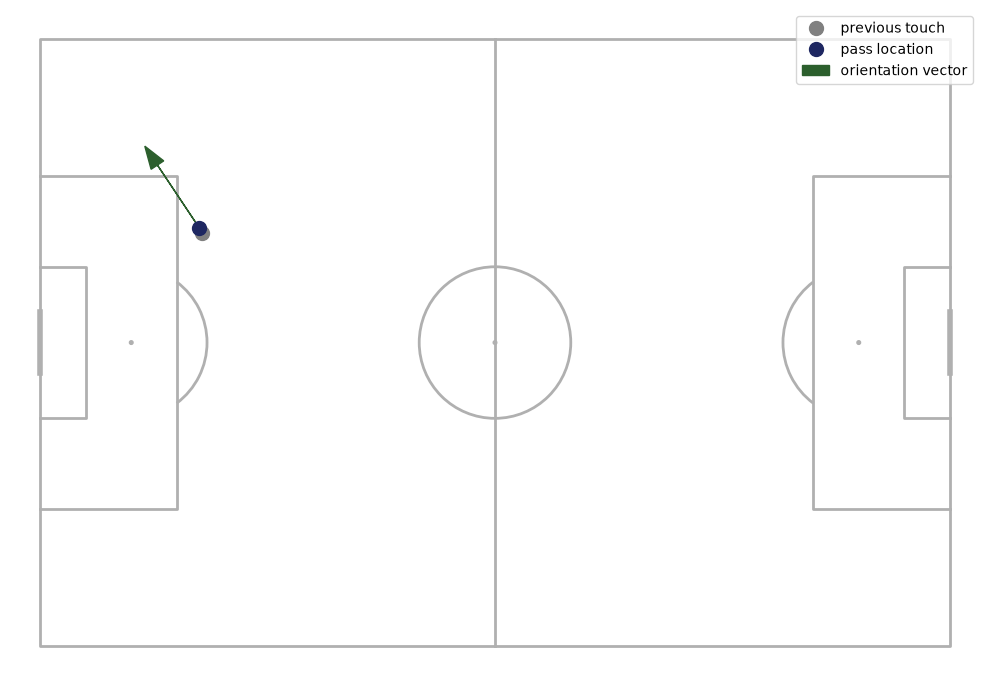

In [9]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# grab one valid example
example = passes[passes['orientation_vector'].notna()].iloc[10]

prev_loc = example['prev_location']
curr_loc = example['location']
vec = example['orientation_vector']

pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(10, 7))

# previous location (grey) -> current location (blue)
ax.plot(prev_loc[0], prev_loc[1], 'o', color='grey', markersize=10, label='previous touch')
ax.plot(curr_loc[0], curr_loc[1], 'o', color='#1E2761', markersize=10, label='pass location')

# draw the orientation vector as an arrow from current location
arrow_scale = 10
ax.arrow(curr_loc[0], curr_loc[1], vec[0]*arrow_scale, vec[1]*arrow_scale,
          head_width=2, color='#2C5F2D', label='orientation vector')

ax.legend()
save_fig(plt.gcf(), 'rq1_orientation_vector_example.png')
plt.show()

## 2. The 120 degree vision cone on one pass

For a pass, every teammate in the 360 freeze frame is taken, and the angle between the passer's facing direction and the direction to the teammate is computed (Equation 4.1). A teammate is **visible** if that angle is at most 60 degrees, so inside the 120 degree cone.

In [10]:
def get_teammates_in_frame(match_id, event_id, frames_df, events_df):
    """Get all teammate locations visible in the 360 frame for a given event."""
    frame_rows = frames_df[frames_df['id'] == event_id]
    teammates = frame_rows[(frame_rows['teammate'] == True) & (frame_rows['actor'] == False)]
    return teammates

def angle_to_teammate(passer_loc, passer_orientation, teammate_loc):
    """Compute angle (degrees) between passer's orientation vector and vector to teammate."""
    v_passer = np.array(passer_orientation)
    v_teammate = np.array([teammate_loc[0] - passer_loc[0], teammate_loc[1] - passer_loc[1]])
    
    norm_teammate = np.linalg.norm(v_teammate)
    if norm_teammate == 0:
        return None
    
    v_teammate_unit = v_teammate / norm_teammate
    cos_angle = np.clip(np.dot(v_passer, v_teammate_unit), -1.0, 1.0)
    angle_deg = np.degrees(np.arccos(cos_angle))
    return angle_deg

### The cone on the example pass

**What this shows:** the 8 teammates in this pass's freeze frame are at angles between 36 and 171 degrees from the facing direction. Only the one at 36 degrees is inside the 60 degree limit, so only that teammate is visible.

In [11]:
example_id = example['id']
example_match = example['match_id']

teammates_in_view = get_teammates_in_frame(example_match, example_id, frames, events_sorted)
print(f"{len(teammates_in_view)} teammates in 360 frame for this pass")

teammates_in_view = teammates_in_view.copy()
teammates_in_view['angle_to_passer_orientation'] = teammates_in_view['location'].apply(
    lambda loc: angle_to_teammate(curr_loc, vec, loc)
)
teammates_in_view['visible'] = teammates_in_view['angle_to_passer_orientation'] <= 60

print(teammates_in_view[['location', 'angle_to_passer_orientation', 'visible']])

8 teammates in 360 frame for this pass
                                     location  angle_to_passer_orientation  \
964  [14.269641836890372, 41.545479543793334]                   124.294701   
965  [15.724293881701854, 28.611986436361466]                    91.440149   
967    [19.74153904490182, 49.91251814205276]                   143.429625   
971  [21.136099666255163, 21.555430141641107]                    36.020303   
973    [23.81814644414058, 43.95543692695858]                   154.722539   
975  [31.138073215642333, 22.833846975809948]                   112.170865   
976  [36.225336278148134, 57.500616666681495]                   171.343731   
977    [41.05062588495932, 39.22565175863359]                   159.234890   

     visible  
964    False  
965    False  
967    False  
971     True  
973    False  
975    False  
976    False  
977    False  


The passer, the facing direction, the edges of the cone (dashed) and every teammate (visible or not) are drawn on the pitch.

saved ..\data\results\figures\rq1_vision_cone_diagram.png


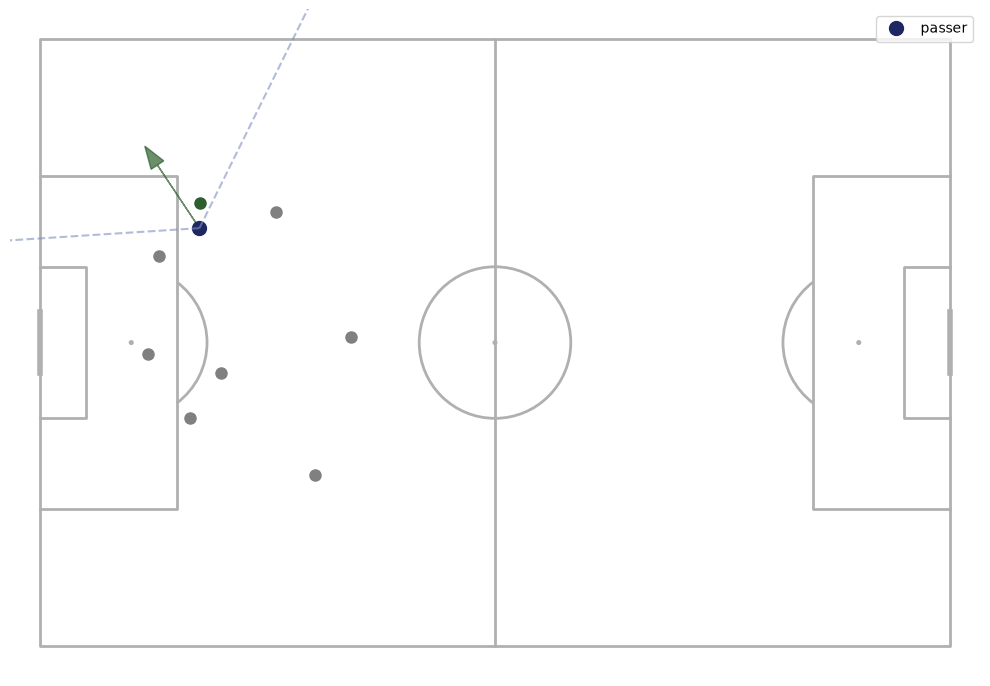

In [12]:
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(10, 7))

# passer and orientation arrow
ax.plot(curr_loc[0], curr_loc[1], 'o', color='#1E2761', markersize=10, label='passer')
ax.arrow(curr_loc[0], curr_loc[1], vec[0]*10, vec[1]*10,
          head_width=2, color='#2C5F2D', alpha=0.7, label='facing direction')

# draw the 120° cone as two boundary lines at ±60° from orientation
angle_center = np.degrees(np.arctan2(vec[1], vec[0]))
for offset in [-60, 60]:
    boundary_angle = np.radians(angle_center + offset)
    bx = curr_loc[0] + 40 * np.cos(boundary_angle)
    by = curr_loc[1] + 40 * np.sin(boundary_angle)
    ax.plot([curr_loc[0], bx], [curr_loc[1], by], '--', color='#7F8FC0', alpha=0.6,
            label='edge of the 120 degree cone' if offset == -60 else None)

# teammates: green if visible, grey if not (each label added once for the legend)
labelled = set()
for _, row in teammates_in_view.iterrows():
    color = '#2C5F2D' if row['visible'] else 'grey'
    label = 'visible teammate' if row['visible'] else 'invisible teammate'
    ax.plot(row['location'][0], row['location'][1], 'o', color=color, markersize=8,
            label=None if label in labelled else label)
    labelled.add(label)

ax.legend()
save_fig(plt.gcf(), 'rq1_vision_cone_diagram.png')
plt.show()

**What this shows:** only the teammate inside the cone is marked visible, so the geometry of Layer 1 works on a single pass. The next step applies it to every pass in the match.

## 3. The vision cone on every pass of the match

The same classification is run for every pass in the match with a facing direction. For each pass, every teammate in its freeze frame is marked visible or invisible. This is the per-pass output RQ1 needs: how many teammates were visible and invisible, and which ones.

In [13]:
def classify_pass_visibility(passer_loc, passer_orientation, match_id, event_id, frames_df):
    """
    For one pass, return all teammates in its 360 frame with angle-to-orientation
    and visibility classification.
    """
    teammates = get_teammates_in_frame(match_id, event_id, frames_df, None)
    
    if teammates.empty:
        return None
    
    teammates = teammates.copy()
    teammates['angle_to_orientation'] = teammates['location'].apply(
        lambda loc: angle_to_teammate(passer_loc, passer_orientation, loc)
    )
    teammates = teammates.dropna(subset=['angle_to_orientation'])
    teammates['visible'] = teammates['angle_to_orientation'] <= 60
    
    return teammates

### Applying the classifier to all passes

Each pass with a facing direction is classified, and the number of teammates in the frame, visible and invisible, is recorded. Passes without a 360 frame (for example events off camera) are counted separately.

In [14]:
import pandas as pd

results = []

valid_passes = passes[passes['orientation_vector'].notna()]

for _, row in valid_passes.iterrows():
    classified = classify_pass_visibility(
        passer_loc=row['location'],
        passer_orientation=row['orientation_vector'],
        match_id=row['match_id'],
        event_id=row['id'],
        frames_df=frames
    )
    
    if classified is None or classified.empty:
        results.append({
            'pass_id': row['id'],
            'has_360_frame': False,
            'n_teammates': 0,
            'n_visible': 0,
            'n_invisible': 0
        })
    else:
        results.append({
            'pass_id': row['id'],
            'has_360_frame': True,
            'n_teammates': len(classified),
            'n_visible': int(classified['visible'].sum()),
            'n_invisible': int((~classified['visible']).sum())
        })

pass_visibility = pd.DataFrame(results)
print(f"{len(pass_visibility)} passes processed")
print(f"{pass_visibility['has_360_frame'].sum()} had usable 360 frame data")

804 passes processed
667 had usable 360 frame data


### How many passes survive each step

Each filter removes some passes, and the final sample is smaller than the raw pass count. The steps are:

- all passes in the match;
- passes with a facing direction, which needs a previous touch by the same player;
- passes with a 360 frame, which needs StatsBomb to have captured a freeze frame for that event.

Both exclusions are expected, and they are reported as part of the method.

In [15]:
total_passes = len(passes)
with_orientation = len(valid_passes)
with_360 = pass_visibility['has_360_frame'].sum()

print(f"Total passes in match:              {total_passes}")
print(f"With valid orientation proxy:       {with_orientation} ({with_orientation/total_passes:.1%})")
print(f"With usable 360 frame data:         {with_360} ({with_360/total_passes:.1%})")
print(f"Final clean sample for Layer 1:     {with_360} ({with_360/total_passes:.1%} of total)")

Total passes in match:              915
With valid orientation proxy:       804 (87.9%)
With usable 360 frame data:         667 (72.9%)
Final clean sample for Layer 1:     667 (72.9% of total)


### How many teammates are visible

For the passes that remain, the number of visible and invisible teammates per pass. This is the first result of the project: how much of the pitch a player can realistically see at the moment of a pass, compared with the number of teammates on it.

In [16]:
clean = pass_visibility[pass_visibility['has_360_frame']]

print("Teammates in 360 frame per pass:")
print(clean['n_teammates'].describe())

print("\nVisible teammates per pass:")
print(clean['n_visible'].describe())

print("\nInvisible teammates per pass:")
print(clean['n_invisible'].describe())

print(f"\nOn average, {clean['n_visible'].mean():.2f} of {clean['n_teammates'].mean():.2f} "
      f"teammates in frame were within the 120° cone "
      f"({clean['n_visible'].mean()/clean['n_teammates'].mean():.1%})")

Teammates in 360 frame per pass:
count    667.000000
mean       7.170915
std        1.624935
min        1.000000
25%        6.000000
50%        7.000000
75%        8.000000
max       10.000000
Name: n_teammates, dtype: float64

Visible teammates per pass:
count    667.000000
mean       2.371814
std        1.968136
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       10.000000
Name: n_visible, dtype: float64

Invisible teammates per pass:
count    667.000000
mean       4.799100
std        2.115678
min        0.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       10.000000
Name: n_invisible, dtype: float64

On average, 2.37 of 7.17 teammates in frame were within the 120° cone (33.1%)


### A consistency check

`n_visible` has a maximum of 10, while `n_teammates` has a mean of about 7. This checks that `n_visible` never exceeds `n_teammates` on any pass, which would indicate a bug in the classification.

In [17]:
bad_rows = clean[clean['n_visible'] > clean['n_teammates']]
print(f"Passes where n_visible > n_teammates: {len(bad_rows)}")
print(bad_rows[['pass_id', 'n_teammates', 'n_visible', 'n_invisible']])

Passes where n_visible > n_teammates: 0
Empty DataFrame
Columns: [pass_id, n_teammates, n_visible, n_invisible]
Index: []


### Saving the Layer 1 output for this match

The per-pass visibility classification is saved. It is the input to Layer 2 and to the RQ1 comparison.

In [18]:
import os
os.makedirs('../data', exist_ok=True)

clean.to_parquet('../data/euro2024_final_pass_visibility.parquet')
valid_passes.to_parquet('../data/euro2024_final_passes_with_orientation.parquet')

print("Saved:")
print("  ../data/euro2024_final_pass_visibility.parquet")
print("  ../data/euro2024_final_passes_with_orientation.parquet")

Saved:
  ../data/euro2024_final_pass_visibility.parquet
  ../data/euro2024_final_passes_with_orientation.parquet


### Moving the functions into `src/`

`compute_orientation_vector`, `angle_to_teammate`, `get_teammates_in_frame` and `classify_pass_visibility` are reused for every match, so they are moved to `src/vision_cone.py` and imported from there.

In [19]:
import sys
sys.path.append('..')
from src.vision_cone import add_orientation_vectors, build_pass_visibility_table

# re-run the whole pipeline using the src module, should match your existing results
events_check = add_orientation_vectors(events)
passes_check = events_check[events_check['type'] == 'Pass'].copy()
visibility_check = build_pass_visibility_table(passes_check, frames)

print(visibility_check['has_360_frame'].sum(), "passes with usable 360 data (should be 667)")

667 passes with usable 360 data (should be 667)


## 4. Valuing actions with VAEP

Layer 1 says which teammates were visible at each pass. To answer RQ1, passes also need a value, to judge whether the chosen pass was better or worse than the visible alternatives.

socceraction provides the VAEP framework (SPADL conversion, features and the VAEP formula) but no trained model. The scoring and conceding models have to be trained on the data used here. One match (about 3300 actions and three goals) is far too small to train them, so this section only checks the pipeline on one match. The models are trained on the full Euro 2024 data in the following steps.

This step uses socceraction's own `StatsBombLoader`, separate from `statsbombpy` used for Layer 1, because its output is the format `convert_to_actions` expects.

In [20]:
from socceraction.data.statsbomb import StatsBombLoader
import socceraction.spadl as spadl

SBL = StatsBombLoader(getter="remote")

games = SBL.games(competition_id=COMPETITION_ID, season_id=SEASON_ID)
game_row = games[games['game_id'] == int(match_id)]
print(game_row[['game_id', 'home_team_id', 'away_team_id', 'game_date']])

    game_id  home_team_id  away_team_id           game_date
22  3943043           772           768 2024-07-14 19:00:00


### Converting the match to SPADL

SPADL (Soccer Player Action Description Language) is socceraction's standard action format, a cleaned version of the raw event stream that VAEP's features expect.

In [21]:
home_team_id = int(game_row['home_team_id'].iloc[0])

sb_events = SBL.events(game_id=int(match_id))
actions = spadl.statsbomb.convert_to_actions(sb_events, home_team_id=home_team_id)

print(f"{len(actions)} actions converted")
actions.head()

1877 actions converted


,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id
0,3943043,277afcf7-04cb-4768-b41c-2b421d657d1d,1,0.340,768,99174.0,52.54375,33.9575,82.81875,32.9375,0,1,5,0
1,3943043,4a701432-ef81-4b8d-aad8-0eda8205610c,1,2.870,768,3468.0,82.81875,32.9375,79.93125,26.8175,21,1,0,1
2,3943043,76458596-db8b-457e-952a-5f0b1bdfdb71,1,4.742,768,3468.0,79.93125,26.8175,0.04375,57.5025,0,0,4,2
3,3943043,9e7d4081-2230-4b76-af41-3b00d2cd6ab8,1,34.440,772,11748.0,5.99375,34.3825,7.91875,19.4225,22,1,4,3
4,3943043,fa1cb9c6-cfc7-4379-9ed1-92ed11278435,1,35.658,772,22128.0,7.91875,19.4225,7.74375,19.4225,21,1,0,4


The SPADL output stores action types, results, players and teams as numeric ids. Their names are added to make the conversion easy to check.

In [22]:
teams = SBL.teams(game_id=int(match_id))
players = SBL.players(game_id=int(match_id))

actions_named = (
    spadl.add_names(actions)
    .merge(teams, how='left')
    .merge(players, how='left')
)

actions_named[['period_id', 'time_seconds', 'team_name', 'player_name',
               'type_name', 'result_name', 'start_x', 'start_y', 'end_x', 'end_y']].head(15)

,period_id,time_seconds,team_name,player_name,type_name,result_name,start_x,start_y,end_x,end_y
0,1,0.3400,England,Kobbie Mainoo,pass,success,52.54375,33.9575,82.81875,32.9375
1,1,2.8700,England,Jordan Pickford,dribble,success,82.81875,32.9375,79.93125,26.8175
2,1,4.7420,England,Jordan Pickford,pass,fail,79.93125,26.8175,0.04375,57.5025
3,1,34.4400,Spain,Unai Simón Mendibil,goalkick,success,5.99375,34.3825,7.91875,19.4225
4,1,35.6580,Spain,Robin Aime Robert Le Normand,dribble,success,7.91875,19.4225,7.74375,19.4225
5,1,36.2790,Spain,Robin Aime Robert Le Normand,pass,success,7.74375,19.4225,17.98125,3.6125
6,1,37.6700,Spain,Daniel Carvajal Ramos,dribble,success,17.98125,3.6125,24.98125,3.1025
7,1,39.4360,Spain,Daniel Carvajal Ramos,pass,success,24.98125,3.1025,43.88125,9.8175
8,1,40.5130,Spain,Daniel Olmo Carvajal,dribble,success,43.88125,9.8175,43.09375,9.4775
9,1,40.6450,Spain,Daniel Olmo Carvajal,bad_touch,fail,43.09375,9.4775,43.09375,9.4775


### VAEP features and labels

VAEP describes each action by features of the game state (the last three actions, as in Equation 2.1 of the proposal). Two labels are attached: did the acting team score within the next 10 actions, and did it concede. The scoring and conceding classifiers are trained on these.

Here the features and labels are computed for the one match only, to check that the pipeline runs end to end.

In [23]:
import socceraction.vaep.features as fs
import socceraction.vaep.labels as lab

# gamestates: sequences of the last 3 actions, as VAEP's formula requires
gamestates = fs.gamestates(spadl.add_names(actions), nb_prev_actions=3)

# compute a standard set of VAEP features
feature_functions = [
    fs.actiontype_onehot,
    fs.result_onehot,
    fs.startlocation,
    fs.endlocation,
    fs.team,
    fs.time_delta,
]
X = pd.concat([f(gamestates) for f in feature_functions], axis=1)

# compute labels: scores/concedes within next 10 actions
Y = pd.concat([
    lab.scores(spadl.add_names(actions), nr_actions=10),
    lab.concedes(spadl.add_names(actions), nr_actions=10)
], axis=1)

print(f"Features shape: {X.shape}")
print(f"Labels shape: {Y.shape}")
print(f"\nGoals scored (label=True) in this match: {Y['scores'].sum()}")
print(f"Goals conceded (label=True) in this match: {Y['concedes'].sum()}")
X.head()

Features shape: (1877, 103)
Labels shape: (1877, 2)

Goals scored (label=True) in this match: 29
Goals conceded (label=True) in this match: 1


,actiontype_pass_a0,actiontype_cross_a0,actiontype_throw_in_a0,actiontype_freekick_crossed_a0,actiontype_freekick_short_a0,actiontype_corner_crossed_a0,actiontype_corner_short_a0,actiontype_take_on_a0,actiontype_foul_a0,actiontype_tackle_a0,...,end_x_a0,end_y_a0,end_x_a1,end_y_a1,end_x_a2,end_y_a2,team_1,team_2,time_delta_1,time_delta_2
0,True,False,False,False,False,False,False,False,False,False,...,82.81875,32.9375,82.81875,32.9375,82.81875,32.9375,True,True,0.000,0.000
1,False,False,False,False,False,False,False,False,False,False,...,79.93125,26.8175,82.81875,32.9375,82.81875,32.9375,True,True,2.530,2.530
2,True,False,False,False,False,False,False,False,False,False,...,0.04375,57.5025,79.93125,26.8175,82.81875,32.9375,True,True,1.872,4.402
3,False,False,False,False,False,False,False,False,False,False,...,7.91875,19.4225,0.04375,57.5025,79.93125,26.8175,False,False,29.698,31.570
4,False,False,False,False,False,False,False,False,False,False,...,7.74375,19.4225,7.91875,19.4225,0.04375,57.5025,True,False,1.218,30.916


In [24]:
# Reset index so we can locate actions by position relative to goals

named_actions = spadl.add_names(actions)

named_actions_idx = named_actions.reset_index(drop=True)
Y_idx = Y.reset_index(drop=True)

combined = pd.concat([
    named_actions_idx[['period_id', 'time_seconds', 'team_id', 'type_name', 'result_name']],
    Y_idx[['scores', 'concedes']]
], axis=1)

# find the row index of each goal
goal_rows = combined[(combined['type_name'] == 'shot') & (combined['result_name'] == 'success')].index

for goal_idx in goal_rows:
    scoring_team = combined.loc[goal_idx, 'team_id']
    print(f"\n--- Goal at row {goal_idx}, scored by team_id {scoring_team} ---")
    window = combined.loc[max(0, goal_idx - 10):goal_idx]
    print(window)


--- Goal at row 1001, scored by team_id 772 ---
      period_id  time_seconds  team_id type_name result_name  scores  concedes
991           2        51.674      772      pass     success   False     False
992           2        52.486      772   dribble     success    True     False
993           2        53.648      772      pass     success    True     False
994           2        55.959      772   dribble     success    True     False
995           2        59.552      772      pass     success    True     False
996           2        61.817      772   dribble     success    True     False
997           2        62.313      772      pass     success    True     False
998           2        63.744      772      pass     success    True     False
999           2        66.123      772   dribble     success    True     False
1000          2        68.079      772      pass     success    True     False
1001          2        69.977      772      shot     success    True     False

--

### Why so few conceding labels?

In this match, `scores` has 29 positive labels and `concedes` only 1, although the two are defined symmetrically.

**What this shows:** the asymmetry is not a bug.

- `lab.scores()` marks an action if the acting team scores within the next 10 actions.
- `lab.concedes()` marks an action if the acting team concedes within the next 10 actions.

In 2 of the 3 goals, the conceding team made no action at all in the 10 actions before the goal, because the scoring team kept the ball all the way to the goal. So there was nothing for `concedes` to mark. The one positive `concedes` label is a foul by the conceding team before England's goal.

This illustrates how sparse the labels are in one match: with a single positive `concedes` label, no classifier could learn from this game alone. The models are therefore trained on the full competition, where many more goals and defensive sequences give both labels enough positives.

### Running the pipeline on all 51 Euro 2024 matches

Everything so far (vision cone, SPADL conversion, features and labels) has been checked on one match. It is now run for every match of the competition, saving one file per match. This gives the VAEP classifiers enough goals to learn from, and the RQ1 comparison a full competition rather than one match.

In [25]:
import os
os.makedirs('../data/matches', exist_ok=True)

all_matches = matches['match_id'].tolist()
print(f"{len(all_matches)} matches to process")

failed_matches = []

for i, mid in enumerate(all_matches):
    save_path = f'../data/matches/match_{mid}.pkl'
    if os.path.exists(save_path):
        continue  # already processed, skip

    try:
        # Layer 1: vision cone
        m_events = sb.events(match_id=mid)
        m_frames = sb.frames(match_id=mid, fmt='dataframe')
        m_events_oriented = add_orientation_vectors(m_events)
        m_passes = m_events_oriented[m_events_oriented['type'] == 'Pass'].copy()
        m_visibility = build_pass_visibility_table(m_passes, m_frames)

        # SPADL conversion + VAEP features/labels
        m_game_row = games[games['game_id'] == int(mid)]
        m_home_id = int(m_game_row['home_team_id'].iloc[0])
        m_sb_events = SBL.events(game_id=int(mid))
        m_actions = spadl.statsbomb.convert_to_actions(m_sb_events, home_team_id=m_home_id)
        m_named = spadl.add_names(m_actions)

        m_gamestates = fs.gamestates(m_named, nb_prev_actions=3)
        m_X = pd.concat([f(m_gamestates) for f in feature_functions], axis=1)
        m_Y = pd.concat([lab.scores(m_named, nr_actions=10), lab.concedes(m_named, nr_actions=10)], axis=1)

        pd.to_pickle(
            {'visibility': m_visibility, 'actions': m_named, 'X': m_X, 'Y': m_Y},
            save_path
        )
        print(f"[{i+1}/{len(all_matches)}] match {mid} done")

    except Exception as e:
        print(f"[{i+1}/{len(all_matches)}] match {mid} FAILED: {e}")
        failed_matches.append(mid)

print(f"\nDone. {len(failed_matches)} matches failed: {failed_matches}")

51 matches to process

Done. 0 matches failed: []


### Combining the matches

The per-match files are combined into competition-wide tables: the pass visibility (Layer 1 output), and the features (X) and labels (Y) for training VAEP.

In [26]:
import glob

match_files = glob.glob('../data/matches/match_*.pkl')
print(f"{len(match_files)} match files found")

all_visibility = []
all_actions = []
all_X = []
all_Y = []

for f in match_files:
    data = pd.read_pickle(f)
    all_visibility.append(data['visibility'])
    all_actions.append(data['actions'])
    all_X.append(data['X'])
    all_Y.append(data['Y'])

visibility_full = pd.concat(all_visibility, ignore_index=True)
actions_full = pd.concat(all_actions, ignore_index=True)
X_full = pd.concat(all_X, ignore_index=True)
Y_full = pd.concat(all_Y, ignore_index=True)

print(f"Total passes classified (Layer 1): {len(visibility_full)}")
print(f"Total actions (actions_full): {actions_full.shape}")
print(f"Total actions for VAEP (X): {X_full.shape}")
print(f"Total actions for VAEP (Y): {Y_full.shape}")

51 match files found
Total passes classified (Layer 1): 46593
Total actions (actions_full): (109985, 17)
Total actions for VAEP (X): (109985, 103)
Total actions for VAEP (Y): (109985, 2)


### Training the VAEP models

VAEP needs two gradient boosting classifiers, one for P(scores) and one for P(concedes), each trained on the game-state features. A held-out split gives an honest estimate of how well they discriminate before they are used to value every action, including the counterfactual passes.

The 51 matches (109985 actions) are a modest training set compared with typical VAEP implementations trained on full seasons. This is reported as a limitation.

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss

X_train, X_test, Y_train, Y_test = train_test_split(
    X_full, Y_full, test_size=0.2, random_state=42
)

models = {}
for label in ['scores', 'concedes']:
    print(f"Training model for '{label}'...")
    model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    model.fit(X_train, Y_train[label])
    models[label] = model

    preds = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(Y_test[label], preds)
    brier = brier_score_loss(Y_test[label], preds)
    print(f"  {label}: AUC = {auc:.3f}, Brier score = {brier:.4f}")

Training model for 'scores'...
  scores: AUC = 0.747, Brier score = 0.0072
Training model for 'concedes'...
  concedes: AUC = 0.784, Brier score = 0.0031


**What this shows:** AUC measures how well each model separates actions that were soon followed by a goal from those that were not (0.5 is random, 1.0 is perfect). The values of 0.747 (scores) and 0.784 (concedes) are in line with the original VAEP paper, despite the much smaller dataset.

The Brier score measures calibration (0 is perfect). Its very low values mostly reflect how rare goals are, so on their own they do not show an unusually good model.

saved ..\data\results\figures\rq1_roc_curves.png


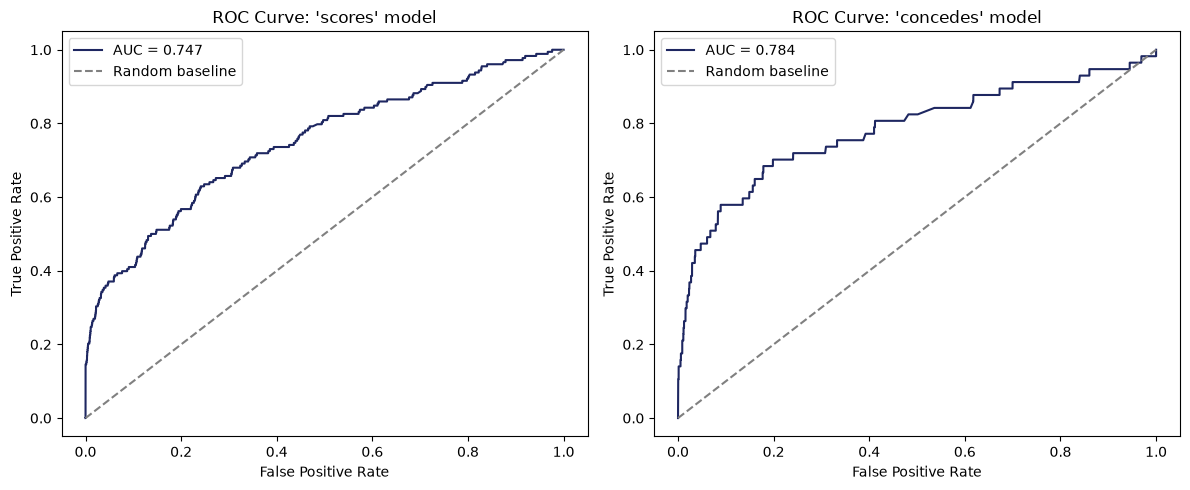

In [28]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, label in zip(axes, ['scores', 'concedes']):
    preds = models[label].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test[label], preds)
    auc = roc_auc_score(Y_test[label], preds)
    
    ax.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], '--', color='grey', label='Random baseline')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f"ROC Curve: '{label}' model")
    ax.legend()

plt.tight_layout()
save_fig(plt.gcf(), 'rq1_roc_curves.png')
plt.show()

### Cross-validation and training curves

A single split gives one AUC, which says nothing about how much it varies, or whether the model overfits as boosting stages are added. Three checks:

1. **Stratified 5-fold cross-validation.** It gives a mean AUC and its spread across five splits. Stratifying matters because goals are rare.
2. **Training and validation loss curves.** Loss at each of the 100 boosting stages, on training and held-out data. Validation loss rising while training loss falls would mean overfitting.
3. **Stability across seeds.** The model is refitted with 10 random seeds to show how consistent training is.

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_results = {}
for label in ['scores', 'concedes']:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    cv_scores = cross_val_score(cv_model, X_full, Y_full[label], cv=skf, scoring='roc_auc')
    cv_results[label] = cv_scores
    print(f"{label}: AUC = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  (5-fold CV)")
    print(f"  individual folds: {[f'{s:.3f}' for s in cv_scores]}")

scores: AUC = 0.739 ± 0.007  (5-fold CV)
  individual folds: ['0.733', '0.744', '0.728', '0.747', '0.744']
concedes: AUC = 0.751 ± 0.033  (5-fold CV)
  individual folds: ['0.764', '0.782', '0.740', '0.776', '0.692']


saved ..\data\results\figures\rq1_training_curves.png


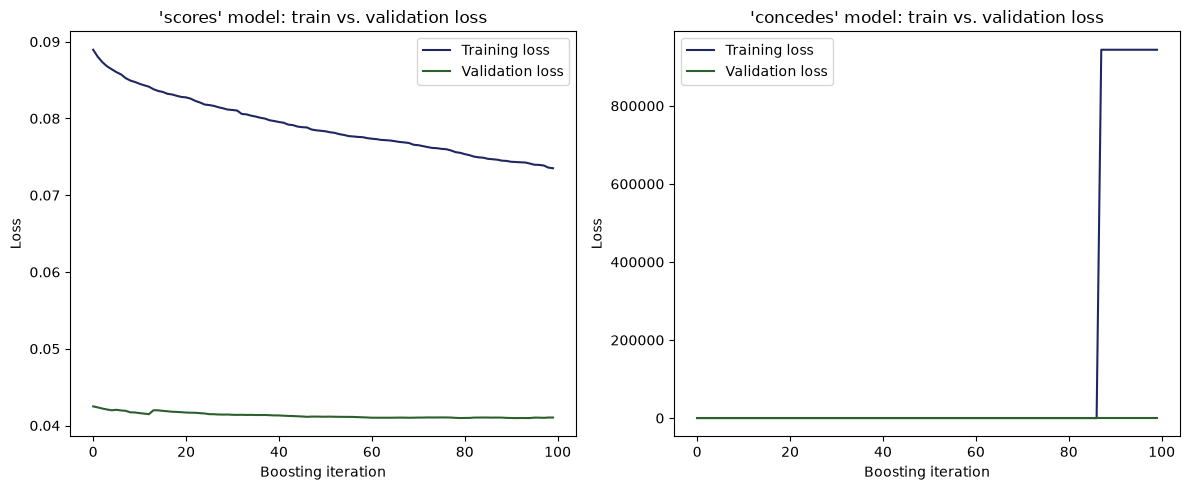

In [30]:
from sklearn.metrics import log_loss

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, label in zip(axes, ['scores', 'concedes']):
    diag_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    diag_model.fit(X_train, Y_train[label])

    train_loss = diag_model.train_score_  # deviance at each boosting stage, on training data

    test_loss = []
    for y_pred_proba in diag_model.staged_predict_proba(X_test):
        test_loss.append(log_loss(Y_test[label], y_pred_proba[:, 1]))

    ax.plot(train_loss, label='Training loss')
    ax.plot(test_loss, label='Validation loss')
    ax.set_xlabel('Boosting iteration')
    ax.set_ylabel('Loss')
    ax.set_title(f"'{label}' model: train vs. validation loss")
    ax.legend()

plt.tight_layout()
save_fig(plt.gcf(), 'rq1_training_curves.png')
plt.show()

saved ..\data\results\figures\rq1_concedes_curve.png


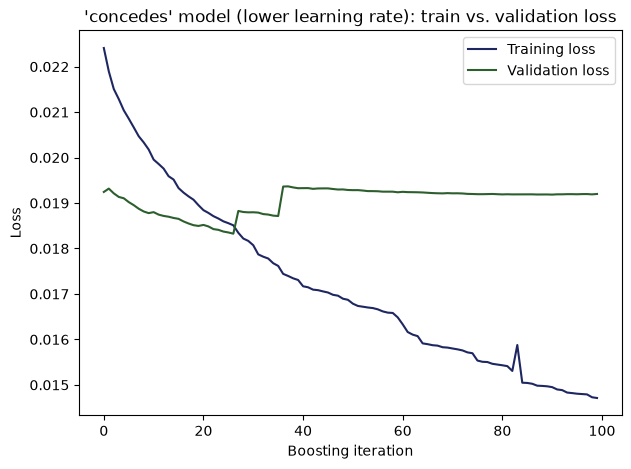

New concedes AUC: 0.823


In [31]:
concedes_model_v2 = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42
)
concedes_model_v2.fit(X_train, Y_train['concedes'])

test_loss_v2 = [log_loss(Y_test['concedes'], p[:, 1]) for p in concedes_model_v2.staged_predict_proba(X_test)]
train_loss_v2 = concedes_model_v2.train_score_

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_loss_v2, label='Training loss')
ax.plot(test_loss_v2, label='Validation loss')
ax.set_xlabel('Boosting iteration')
ax.set_ylabel('Loss')
ax.set_title("'concedes' model (lower learning rate): train vs. validation loss")
ax.legend()
save_fig(plt.gcf(), 'rq1_concedes_curve.png')
plt.show()

print(f"New concedes AUC: {roc_auc_score(Y_test['concedes'], concedes_model_v2.predict_proba(X_test)[:,1]):.3f}")

In [32]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
concedes_fixed_cv = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
concedes_fixed_scores = cross_val_score(concedes_fixed_cv, X_full, Y_full['concedes'], cv=skf, scoring='roc_auc')

print(f"concedes (after fix, 5-fold CV): {concedes_fixed_scores.mean():.3f} \u00b1 {concedes_fixed_scores.std():.3f}")
print(f"individual folds: {[f'{s:.3f}' for s in concedes_fixed_scores]}")

concedes (after fix, 5-fold CV): 0.813 ± 0.034
individual folds: ['0.773', '0.864', '0.832', '0.817', '0.780']


**What this shows:** the conceding model was unstable because positive labels are so rare: its validation loss spiked during training. Lowering the learning rate removed the spike and raised the mean AUC from 0.751 to 0.813.

The spread across folds did not shrink (0.033 against 0.034, with folds from 0.773 to 0.864). So the lower learning rate fixed the instability and improved average performance. The remaining variation between folds reflects having only 202 positive examples.

### Calibration

VAEP values an action by the change in probability between consecutive game states ($\Delta P = P(S_i) - P(S_{i-1})$). The predicted probabilities therefore need to be calibrated against the real goal rates, not just rank actions well. Calibration curves (reliability diagrams) and the distribution of predicted probabilities are shown for $P(\text{scores})$ and $P(\text{concedes})$.

saved ..\data\results\figures\rq1_calibration_curves.png


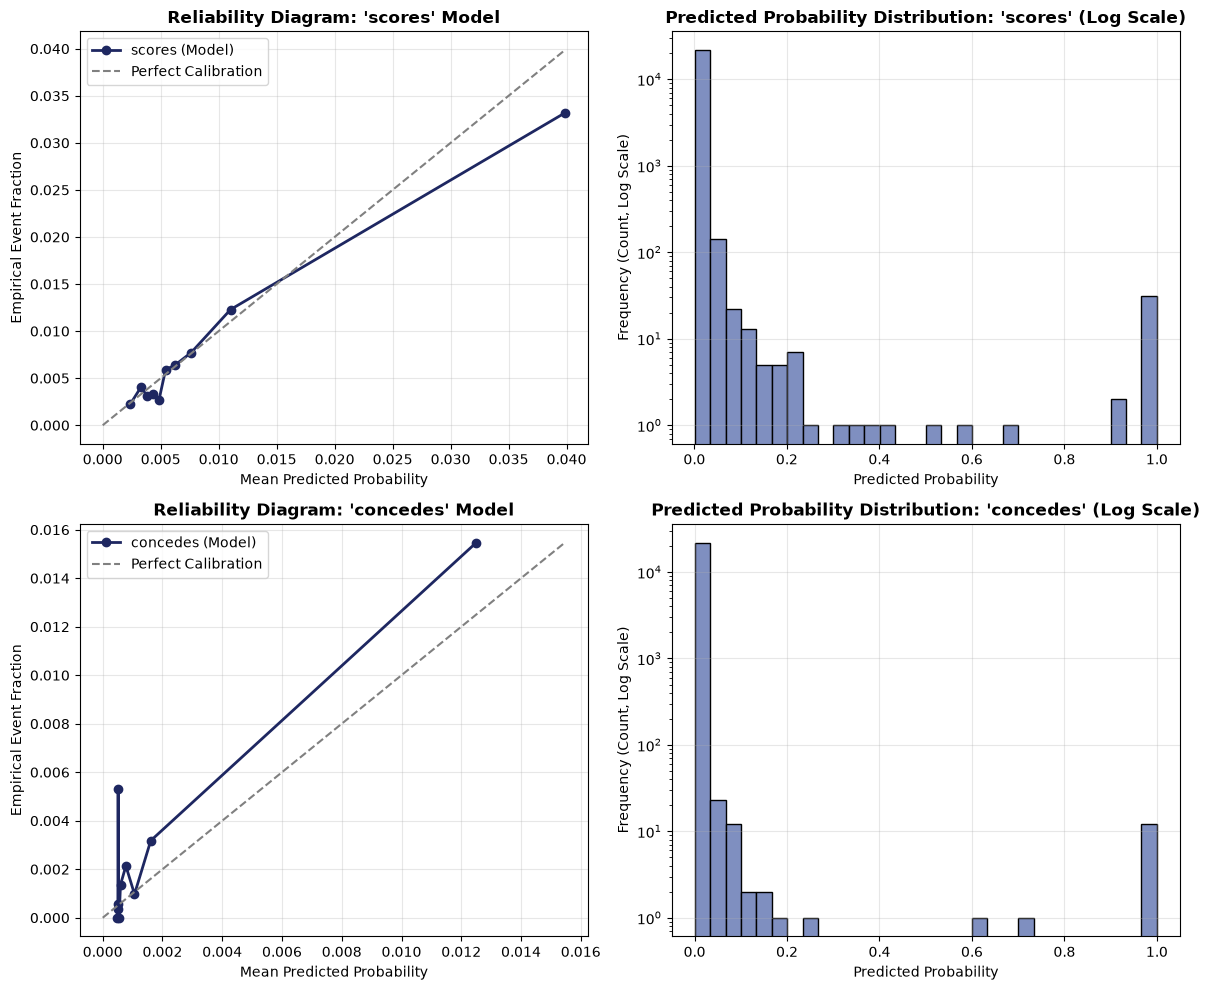

In [33]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Models to evaluate
eval_models = {
    'scores': models['scores'],
    'concedes': concedes_model_v2
}

for idx, (label, model) in enumerate(eval_models.items()):
    # Predict probabilities on test set
    prob_pos = model.predict_proba(X_test)[:, 1]
    
    # Compute calibration curve
    prob_true, prob_pred = calibration_curve(Y_test[label], prob_pos, n_bins=10, strategy='quantile')
    
    # Plot Reliability Curve
    ax_cal = axes[idx, 0]
    ax_cal.plot(prob_pred, prob_true, marker='o', linewidth=2, label=f'{label} (Model)')
    ax_cal.plot([0, max(prob_pred.max(), prob_true.max())], 
                [0, max(prob_pred.max(), prob_true.max())], 
                linestyle='--', color='gray', label='Perfect Calibration')
    ax_cal.set_title(f"Reliability Diagram: '{label}' Model", fontsize=12, fontweight='bold')
    ax_cal.set_xlabel("Mean Predicted Probability", fontsize=10)
    ax_cal.set_ylabel("Empirical Event Fraction", fontsize=10)
    ax_cal.legend(loc='upper left')
    ax_cal.grid(alpha=0.3)
    
    # Plot Probability Distribution (Log Scale)
    ax_dist = axes[idx, 1]
    ax_dist.hist(prob_pos, bins=30, color='#7F8FC0', edgecolor='black', log=True)
    ax_dist.set_title(f"Predicted Probability Distribution: '{label}' (Log Scale)", fontsize=12, fontweight='bold')
    ax_dist.set_xlabel("Predicted Probability", fontsize=10)
    ax_dist.set_ylabel("Frequency (Count, Log Scale)", fontsize=10)
    ax_dist.grid(alpha=0.3)

plt.tight_layout()
save_fig(plt.gcf(), 'rq1_calibration_curves.png')
plt.show()

**What this shows**

**Both models are well calibrated.** Their curves follow the diagonal across the range of predicted probabilities (0 to 4 percent for scoring, 0 to 1.6 percent for conceding). So the gradient boosted trees give probabilities that match the real goal rates.

**The changes in probability can be used directly as values.** Because the probabilities are not inflated, the changes $\Delta P(\text{scores})$ and $\Delta P(\text{concedes})$ can be read as goal value added by each action, without further calibration.

saved ..\data\results\figures\rq1_multi_seed_curves.png


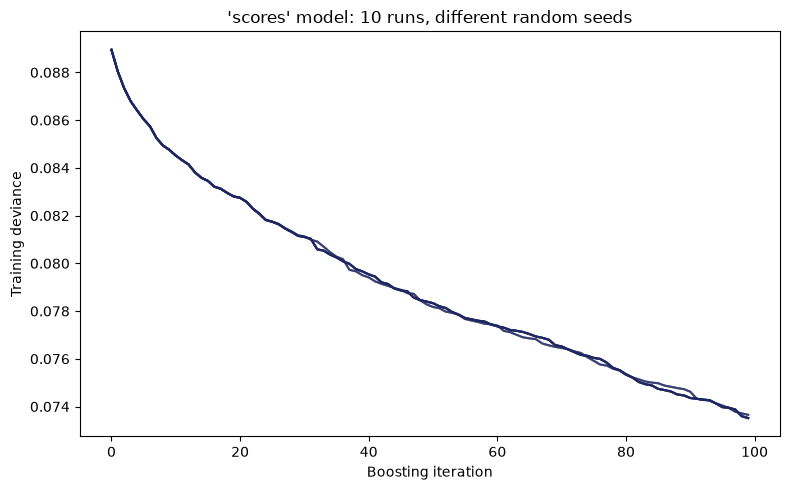

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
for seed in range(10):
    seed_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=seed)
    seed_model.fit(X_train, Y_train['scores'])
    ax.plot(seed_model.train_score_, alpha=0.5, color='#1E2761')
ax.set_xlabel('Boosting iteration')
ax.set_ylabel('Training deviance')
ax.set_title("'scores' model: 10 runs, different random seeds")
plt.tight_layout()
save_fig(plt.gcf(), 'rq1_multi_seed_curves.png')
plt.show()

### VAEP values for every action

With both models trained, every action gets a VAEP value using Equation 2.1 of the proposal: the change in P(scores) minus the change in P(concedes), from before to after the action. This value is the basis for comparing chosen passes with their alternatives in RQ1.

In [35]:
from socceraction.vaep.formula import value

Pscores = models['scores'].predict_proba(X_full)[:, 1]
Pconcedes = models['concedes'].predict_proba(X_full)[:, 1]

action_values = value(
    actions_full.reset_index(drop=True),
    pd.Series(Pscores),
    pd.Series(Pconcedes)
)

print(action_values.describe())
print(f"\nHighest-value actions:")
top_actions = pd.concat([actions_full.reset_index(drop=True), action_values], axis=1)
top_actions.sort_values('vaep_value', ascending=False)[
    ['type_name', 'result_name', 'team_id', 'vaep_value']
].head(10)

       offensive_value  defensive_value     vaep_value
count    109985.000000    109985.000000  109985.000000
mean          0.001517         0.000016       0.001533
std           0.036103         0.029243       0.045698
min          -0.995680        -1.000000      -1.524094
25%          -0.000767        -0.000094      -0.000791
50%           0.000368         0.000000       0.000381
75%           0.002085         0.000197       0.002323
max           1.000000         0.999953       1.064986

Highest-value actions:


,type_name,result_name,team_id,vaep_value
21766,shot,success,770,1.064986
80279,dribble,success,768,1.018086
102024,dribble,success,771,1.010341
91202,shot,success,909,1.009009
2098,pass,success,773,1.005639
23922,shot,success,773,1.005577
59674,shot,success,905,1.005297
24603,dribble,success,773,1.003334
37974,shot,success,782,1.002164
68881,dribble,success,771,1.001152


saved ..\data\results\figures\rq1_vaep_value_distribution.png


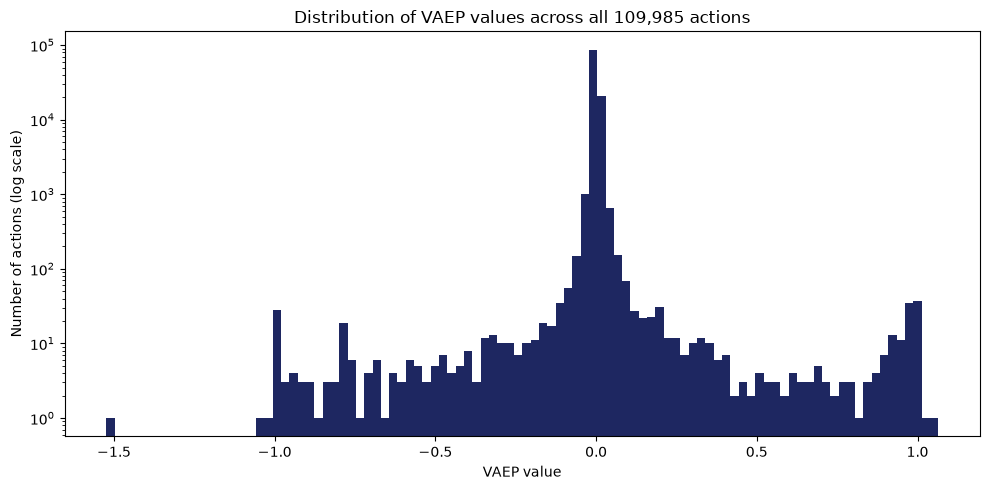

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(action_values['vaep_value'], bins=100, color='#1E2761', edgecolor='none')
ax.set_yscale('log')
ax.set_xlabel('VAEP value')
ax.set_ylabel('Number of actions (log scale)')
ax.set_title('Distribution of VAEP values across all 109,985 actions')
plt.tight_layout()
save_fig(plt.gcf(), 'rq1_vaep_value_distribution.png')
plt.show()

**What this shows:** all 109985 actions in the 51 matches now have a VAEP value, the change they made to the team's chance of scoring minus their chance of conceding. The distribution is centred just above zero (most actions change little) with a long right tail of valuable actions. The highest-valued actions are shots and dribbles into dangerous positions, which is what football sense expects.

## 5. Counterfactual passes

### Excluding goal assists

A pass that directly assisted a goal has already achieved close to the highest possible value, so asking whether a better alternative existed is close to meaningless. These passes are excluded from the counterfactual comparison in RQ1 and RQ2.

In [37]:
goal_assist_ids = set()

for f in match_files:
    mid = f.split('match_')[1].split('.pkl')[0]
    m_events = sb.events(match_id=mid)
    
    if 'pass_goal_assist' in m_events.columns:
        assists = m_events[m_events['pass_goal_assist'] == True]['id'].tolist()
        goal_assist_ids.update(assists)

print(f"{len(goal_assist_ids)} goal-assist passes found across all 51 matches (to be excluded from counterfactual search)")

70 goal-assist passes found across all 51 matches (to be excluded from counterfactual search)


**What this shows:** only the assist itself is excluded. Earlier passes in the move are kept, since their VAEP value already reflects their smaller and less certain contribution to the goal.

### A counterfactual pass on one example

For one real pass, a hypothetical version is built for each teammate in the freeze frame, ending at that teammate instead of the actual receiver. The features are recomputed for each hypothetical pass and valued with the trained VAEP models. This checks the method on one pass before it is applied to the full dataset.

In [38]:
print([c for c in actions_full.columns if 'event' in c.lower() or 'id' in c.lower()])

['game_id', 'original_event_id', 'period_id', 'team_id', 'player_id', 'type_id', 'result_id', 'bodypart_id', 'action_id']


In [39]:
sample_match_events = sb.events(match_id="3930158")
sample_events_oriented = add_orientation_vectors(sample_match_events)

candidates = actions_full[
    (actions_full['type_name'] == 'pass') &
    (actions_full['result_name'] == 'success') &
    (~actions_full['original_event_id'].isin(goal_assist_ids))
].copy()

valid_event_ids = set(sample_events_oriented[sample_events_oriented['orientation_vector'].notna()]['id'])
candidates_with_orientation = candidates[candidates['original_event_id'].isin(valid_event_ids)]

sample_pass = candidates_with_orientation.iloc[100]
sample_match_id = str(sample_pass['game_id'])
sample_event_id = sample_pass['original_event_id']

print(sample_pass[['game_id', 'period_id', 'time_seconds', 'team_id', 'player_id',
                     'start_x', 'start_y', 'end_x', 'end_y']])

game_id          3930158
period_id              1
time_seconds     683.802
team_id              942
player_id        10540.0
start_x         48.60625
start_y          11.1775
end_x           35.30625
end_y            13.3025
Name: 267, dtype: object


### The freeze frame for this pass

The counterfactual passes need the teammates' positions at the moment of the pass. `original_event_id` links the SPADL action back to its StatsBomb event id, which is how the 360 frames are indexed.

In [40]:
sample_frames = sb.frames(match_id=sample_match_id, fmt='dataframe')

sample_teammates = sample_frames[
    (sample_frames['id'] == sample_event_id) &
    (sample_frames['teammate'] == True) &
    (sample_frames['actor'] == False)
]

print(f"{len(sample_teammates)} candidate teammates found for this pass")
sample_teammates[['location']]

5 candidate teammates found for this pass


,location
6847,"[63.46276628732333, 48.88820303906155]"
6851,"[70.29474375834607, 29.256284311383503]"
6854,"[77.29004575897987, 2.5390027898185252]"
6855,"[77.32998761610416, 21.817563871697597]"
6856,"[77.79781220304908, 11.592996516015816]"


### Hypothetical passes to each teammate

For each teammate, a copy of the real pass is made with its end location moved to that teammate. Everything else about the game state (who has the ball, when, and the two preceding actions) stays the same; only where the ball goes changes.

In [41]:
# get the real action's row (with all SPADL columns) and its two preceding actions,
# since VAEP features depend on a 3-action window (gamestates)
sample_idx = actions_full.index[actions_full['original_event_id'] == sample_event_id][0]

context_window = actions_full.loc[sample_idx-2:sample_idx].copy()
print("Context window (2 prior actions + the real pass):")
context_window[['type_name', 'result_name', 'start_x', 'start_y', 'end_x', 'end_y']]

Context window (2 prior actions + the real pass):


,type_name,result_name,start_x,start_y,end_x,end_y
265,pass,success,38.01875,3.6975,48.95625,8.8825
266,dribble,success,48.95625,8.8825,48.60625,11.1775
267,pass,success,48.60625,11.1775,35.30625,13.3025


### Visible and invisible teammates for this pass

The vision cone from `src/vision_cone.py` classifies the 9 teammates of this pass, using the same facing direction as Layer 1. This gives the two sets RQ1 compares: all teammates (omniscient) and visible teammates only.

In [42]:
from src.vision_cone import angle_to_teammate

matching_event = sample_events_oriented[sample_events_oriented['id'] == sample_event_id].iloc[0]
passer_loc = matching_event['location']
passer_orientation = matching_event['orientation_vector']

print(f"Passer location: {passer_loc}")
print(f"Orientation vector: {passer_orientation}")

sample_teammates = sample_teammates.copy()
sample_teammates['angle_to_orientation'] = sample_teammates['location'].apply(
    lambda loc: angle_to_teammate(passer_loc, passer_orientation, loc)
)
sample_teammates['visible'] = sample_teammates['angle_to_orientation'] <= 60

print(f"\n{sample_teammates['visible'].sum()} of {len(sample_teammates)} candidates are visible (within 120° cone)")
sample_teammates[['location', 'angle_to_orientation', 'visible']]

Passer location: [64.5, 13.2]
Orientation vector: (0.1465486610894644, 0.9892034623538705)

3 of 5 candidates are visible (within 120° cone)


,location,angle_to_orientation,visible
6847,"[63.46276628732333, 48.88820303906155]",10.091732,True
6851,"[70.29474375834607, 29.256284311383503]",11.417641,True
6854,"[77.29004575897987, 2.5390027898185252]",121.385543,False
6855,"[77.32998761610416, 21.817563871697597]",47.684816,True
6856,"[77.79781220304908, 11.592996516015816]",88.463652,False


### Hypothetical actions for each teammate

For each of the 5 candidates, the real pass is copied with its end location moved to that teammate. The two preceding actions and all other context stay identical, so only the destination changes.

In [43]:
sample_idx = actions_full.index[actions_full['original_event_id'] == sample_event_id][0]
context_window = actions_full.loc[sample_idx-2:sample_idx].copy()

hypothetical_rows = []

for teammate_idx, teammate_row in sample_teammates.iterrows():
    hyp_window = context_window.copy()
    # only the last action (the real pass) gets its end location swapped
    hyp_window.iloc[-1, hyp_window.columns.get_loc('end_x')] = teammate_row['location'][0]
    hyp_window.iloc[-1, hyp_window.columns.get_loc('end_y')] = teammate_row['location'][1]
    hyp_window['candidate_teammate_idx'] = teammate_idx
    hyp_window['visible'] = teammate_row['visible']
    hypothetical_rows.append(hyp_window)

print(f"{len(hypothetical_rows)} hypothetical action windows built")
print("\nExample - real pass end location vs hypothetical:")
print(f"  Real:        end_x={context_window.iloc[-1]['end_x']:.2f}, end_y={context_window.iloc[-1]['end_y']:.2f}")
print(f"  Hypothetical: end_x={hypothetical_rows[0].iloc[-1]['end_x']:.2f}, end_y={hypothetical_rows[0].iloc[-1]['end_y']:.2f}")

5 hypothetical action windows built

Example - real pass end location vs hypothetical:
  Real:        end_x=35.31, end_y=13.30
  Hypothetical: end_x=63.46, end_y=48.89


### Valuing the hypothetical passes

For each hypothetical pass, the same features as for real actions are recomputed (type, result, start and end location, team, time), since a different end location changes, for example, the distance and angle to goal. Each is valued with the trained models, from the same state before the pass as the real one.

In [44]:
hypothetical_values = []

for hyp_window in hypothetical_rows:
    hyp_gamestates = fs.gamestates(hyp_window, nb_prev_actions=3)
    hyp_X = pd.concat([f(hyp_gamestates) for f in feature_functions], axis=1)

    hyp_Pscores = models['scores'].predict_proba(hyp_X)[:, 1]
    hyp_Pconcedes = models['concedes'].predict_proba(hyp_X)[:, 1]

    hyp_window_reset = hyp_window.reset_index(drop=True)

    # pass the FULL window so _prev() shifting works correctly
    hyp_action_value_full = value(
        hyp_window_reset,
        pd.Series(hyp_Pscores),
        pd.Series(hyp_Pconcedes)
    )

    # only the last row (the actual hypothetical pass) is what we care about
    hyp_action_value = hyp_action_value_full.iloc[-1]

    hypothetical_values.append({
        'candidate_teammate_idx': hyp_window['candidate_teammate_idx'].iloc[0],
        'visible': hyp_window['visible'].iloc[0],
        'end_x': hyp_window.iloc[-1]['end_x'],
        'end_y': hyp_window.iloc[-1]['end_y'],
        'hypothetical_vaep_value': hyp_action_value['vaep_value']
    })

hyp_df = pd.DataFrame(hypothetical_values)
print("Hypothetical alternatives:")
hyp_df.sort_values('hypothetical_vaep_value', ascending=False)

Hypothetical alternatives:


,candidate_teammate_idx,visible,end_x,end_y,hypothetical_vaep_value
1,6851,True,70.294744,29.256284,0.001911
3,6855,True,77.329988,21.817564,0.001390
0,6847,True,63.462766,48.888203,0.000550
4,6856,False,77.797812,11.592997,0.000501
2,6854,False,77.290046,2.539003,0.000034


In [45]:
real_action_value = value(
    context_window.reset_index(drop=True),
    pd.Series(models['scores'].predict_proba(
        pd.concat([f(fs.gamestates(context_window, nb_prev_actions=3)) for f in feature_functions], axis=1)
    )[:, 1]),
    pd.Series(models['concedes'].predict_proba(
        pd.concat([f(fs.gamestates(context_window, nb_prev_actions=3)) for f in feature_functions], axis=1)
    )[:, 1])
).iloc[-1]['vaep_value']

print(f"Real pass VAEP value: {real_action_value:.6f}")
print(f"Best omniscient alternative: {hyp_df['hypothetical_vaep_value'].max():.6f}")
print(f"Best visible-only alternative: {hyp_df[hyp_df['visible']]['hypothetical_vaep_value'].max():.6f}")

Real pass VAEP value: 0.000442
Best omniscient alternative: 0.001911
Best visible-only alternative: 0.001911


### Counterfactual values for the whole competition

The single-pass logic is turned into a function that processes one match at a time, over every pass that is not a goal assist and has a facing direction and a 360 frame. For each pass it records:

- the VAEP value of the real pass;
- the best hypothetical value among all teammates (omniscient);
- the best hypothetical value among visible teammates (vision cone).

The same loop also saves the positions of every **invisible** teammate at each pass. These are the targets the Layer 3 LSTM is evaluated against. They are positions only; the trajectory histories the LSTM learns from are built separately in `04_layer3_lstm_sequences.ipynb`.

Results are saved per match, so a rerun skips matches already processed.

In [46]:
import os
os.makedirs('../data/counterfactuals', exist_ok=True)
os.makedirs('../data/lstm_eval', exist_ok=True)

def process_match_counterfactuals(mid):
    m_events = sb.events(match_id=mid)
    m_events_oriented = add_orientation_vectors(m_events)
    m_frames = sb.frames(match_id=mid, fmt='dataframe')

    m_actions = actions_full[actions_full['game_id'] == int(mid)].sort_values('action_id').reset_index(drop=True)

    valid_event_ids = set(m_events_oriented[m_events_oriented['orientation_vector'].notna()]['id'])

    qualifying = m_actions[
        (m_actions['type_name'] == 'pass') &
        (m_actions['result_name'] == 'success') &
        (~m_actions['original_event_id'].isin(goal_assist_ids)) &
        (m_actions['original_event_id'].isin(valid_event_ids))
    ]

    results = []
    lstm_eval_rows = []

    for idx in qualifying.index:
        if idx < 2:
            continue  # not enough prior actions for a 3-action window

        event_id = m_actions.loc[idx, 'original_event_id']
        teammates = m_frames[
            (m_frames['id'] == event_id) &
            (m_frames['teammate'] == True) &
            (m_frames['actor'] == False)
        ]
        if teammates.empty:
            continue

        matching_event = m_events_oriented[m_events_oriented['id'] == event_id].iloc[0]
        passer_loc = matching_event['location']
        passer_orientation = matching_event['orientation_vector']

        teammates = teammates.copy()
        teammates['angle_to_orientation'] = teammates['location'].apply(
            lambda loc: angle_to_teammate(passer_loc, passer_orientation, loc)
        )
        teammates = teammates.dropna(subset=['angle_to_orientation'])
        if teammates.empty:
            continue
        teammates['visible'] = teammates['angle_to_orientation'] <= 60

        # capture invisible teammates' ground-truth locations for later LSTM evaluation (RQ3)
        invisible_teammates = teammates[~teammates['visible']]
        for _, inv in invisible_teammates.iterrows():
            lstm_eval_rows.append({
                'match_id': mid,
                'original_event_id': event_id,
                'teammate_location': inv['location'],
                'passer_location': passer_loc,
                'time_seconds': matching_event.get('timestamp', None)
            })

        context_window = m_actions.loc[idx-2:idx].copy()

        hyp_windows = []
        for _, tm in teammates.iterrows():
            hw = context_window.copy()
            hw.iloc[-1, hw.columns.get_loc('end_x')] = tm['location'][0]
            hw.iloc[-1, hw.columns.get_loc('end_y')] = tm['location'][1]
            hw['visible'] = tm['visible']
            hyp_windows.append(hw)

        hyp_values = []
        for hw in hyp_windows:
            hw_reset = hw.reset_index(drop=True)
            gs = fs.gamestates(hw_reset, nb_prev_actions=3)
            X_hyp = pd.concat([f(gs) for f in feature_functions], axis=1)
            ps = models['scores'].predict_proba(X_hyp)[:, 1]
            pc = models['concedes'].predict_proba(X_hyp)[:, 1]
            v = value(hw_reset, pd.Series(ps), pd.Series(pc)).iloc[-1]['vaep_value']
            hyp_values.append({'visible': hw['visible'].iloc[0], 'value': v})

        hyp_df_row = pd.DataFrame(hyp_values)

        gs_real = fs.gamestates(context_window.reset_index(drop=True), nb_prev_actions=3)
        X_real = pd.concat([f(gs_real) for f in feature_functions], axis=1)
        ps_real = models['scores'].predict_proba(X_real)[:, 1]
        pc_real = models['concedes'].predict_proba(X_real)[:, 1]
        real_value = value(context_window.reset_index(drop=True), pd.Series(ps_real), pd.Series(pc_real)).iloc[-1]['vaep_value']

        visible_only = hyp_df_row[hyp_df_row['visible']]

        results.append({
            'match_id': mid,
            'original_event_id': event_id,
            'real_value': real_value,
            'best_omniscient_value': hyp_df_row['value'].max(),
            'best_visible_value': visible_only['value'].max() if not visible_only.empty else None,
            'n_candidates': len(hyp_df_row),
            'n_visible': int(hyp_df_row['visible'].sum())
        })

    return pd.DataFrame(results), pd.DataFrame(lstm_eval_rows)


all_matches_list = matches['match_id'].tolist()
failed_cf_matches = []

for i, mid in enumerate(all_matches_list):
    save_path = f'../data/counterfactuals/cf_match_{mid}.pkl'
    lstm_save_path = f'../data/lstm_eval/lstm_eval_match_{mid}.pkl'

    if os.path.exists(save_path):
        continue
    try:
        result_df, lstm_eval_df = process_match_counterfactuals(str(mid))
        result_df.to_pickle(save_path)
        lstm_eval_df.to_pickle(lstm_save_path)
        print(f"[{i+1}/{len(all_matches_list)}] match {mid}: {len(result_df)} passes, {len(lstm_eval_df)} invisible-teammate rows saved")
    except Exception as e:
        print(f"[{i+1}/{len(all_matches_list)}] match {mid} FAILED: {e}")
        failed_cf_matches.append(mid)

print(f"\nDone. {len(failed_cf_matches)} matches failed: {failed_cf_matches}")


Done. 0 matches failed: []


In [47]:
import glob

cf_files = glob.glob('../data/counterfactuals/cf_match_*.pkl')
lstm_files = glob.glob('../data/lstm_eval/lstm_eval_match_*.pkl')

print(f"Counterfactual result files: {len(cf_files)} (should be 51)")
print(f"LSTM eval files: {len(lstm_files)} (should be 51)")

Counterfactual result files: 51 (should be 51)
LSTM eval files: 51 (should be 51)


In [48]:
test_load = pd.read_pickle(cf_files[0])
print(test_load.shape)
test_load.head()

(680, 7)


,match_id,original_event_id,real_value,best_omniscient_value,best_visible_value,n_candidates,n_visible
0,3930158,06b36608-b428-452b-a809-ca0a2a0f259b,0.016696,0.001435,NaN,9,0
1,3930158,79aa9f3e-52cc-46f2-a002-8f2ab8fbc171,0.000073,0.002659,0.000073,6,2
2,3930158,865f49e1-6341-421e-89e5-d6e084c1d1ff,-0.002155,-0.000639,-0.001548,7,2
3,3930158,910595a9-e1ff-4be1-98d5-965be6b0905d,0.000389,0.000976,0.000102,7,4
4,3930158,7a31d6b0-c412-4f2f-af93-eea93bc34e69,-0.000513,0.000361,0.000361,6,1


In [49]:
cf_full = pd.concat([pd.read_pickle(f) for f in cf_files], ignore_index=True)

print(f"Total passes with counterfactual comparison: {len(cf_full)}")

cf_valid = cf_full.dropna(subset=['best_visible_value']).copy()
print(f"Passes with at least one visible alternative: {len(cf_valid)}")

cf_valid['value_reduction'] = cf_valid['best_omniscient_value'] - cf_valid['best_visible_value']
cf_valid['identity_changes'] = cf_valid['best_omniscient_value'] != cf_valid['best_visible_value']

print(f"\nMean best omniscient value:    {cf_valid['best_omniscient_value'].mean():.5f}")
print(f"Mean best visible-only value:  {cf_valid['best_visible_value'].mean():.5f}")
print(f"Mean reduction after filtering: {cf_valid['value_reduction'].mean():.5f}")
print(f"\nProportion of passes where filtering changes the optimal alternative: {cf_valid['identity_changes'].mean():.1%}")

from scipy import stats
d = (cf_valid['best_omniscient_value'].mean() - cf_valid['best_visible_value'].mean()) / cf_valid['best_omniscient_value'].std()
print(f"Cohen's d effect size: {d:.3f}")

Total passes with counterfactual comparison: 31537
Passes with at least one visible alternative: 26591

Mean best omniscient value:    0.02562
Mean best visible-only value:  0.01579
Mean reduction after filtering: 0.00983

Proportion of passes where filtering changes the optimal alternative: 59.1%
Cohen's d effect size: 0.089


In [50]:
diffs = cf_valid['best_omniscient_value'] - cf_valid['best_visible_value']
d_paired = diffs.mean() / diffs.std()
print(f"Paired Cohen's d: {d_paired:.3f}")

from scipy.stats import wilcoxon
stat, p = wilcoxon(cf_valid['best_omniscient_value'], cf_valid['best_visible_value'])
print(f"Wilcoxon signed-rank test: statistic={stat:.1f}, p-value={p:.2e}")

Paired Cohen's d: 0.166
Wilcoxon signed-rank test: statistic=0.0, p-value=0.00e+00


### The chosen pass against its alternatives

So far RQ1 compares the best omniscient option with the best visible one. This also compares the pass the player actually made with both, as a first look at the RQ2 question: was the chosen pass already the best visible option, or was a better one available?

In [51]:
print(f"Mean real pass value:          {cf_valid['real_value'].mean():.5f}")
print(f"Mean best omniscient value:    {cf_valid['best_omniscient_value'].mean():.5f}")
print(f"Mean best visible-only value:  {cf_valid['best_visible_value'].mean():.5f}")

# how often was the chosen pass already the best visible option?
cf_valid['chose_best_visible'] = cf_valid['real_value'] >= cf_valid['best_visible_value']
print(f"\nProportion of passes where the chosen pass was already optimal among visible options: {cf_valid['chose_best_visible'].mean():.1%}")

Mean real pass value:          0.00000
Mean best omniscient value:    0.02562
Mean best visible-only value:  0.01579

Proportion of passes where the chosen pass was already optimal among visible options: 27.2%


**Note on the coordinate fix.** The candidate values behind these numbers were computed with a coordinate error, found in `06_layer3_blind_passes.ipynb` and corrected in section 8 of this notebook, where the corrected 166-match results are reported. This cell is kept as the record of the original run.

**What this shows:** in 72.8 percent of passes, the pass the player chose was not the best option among their visible teammates. That is well above the 59.1 percent of passes where the vision cone changes the best option (RQ1), and a first sign that RQ2 may find a substantial effect.

The visible options here are not yet filtered for offside or pass difficulty (xP), which Layer 2 adds. Some of these better options would have been offside or unrealistic to play, so 72.8 percent is an upper bound, not an RQ2 result.

In [52]:
print(cf_valid['real_value'].describe())
print(f"\nMean to more decimal places: {cf_valid['real_value'].mean():.8f}")

count    26591.000000
mean         0.000004
std          0.027097
min         -1.014757
25%         -0.001532
50%         -0.000219
75%          0.001065
max          1.012287
Name: real_value, dtype: float64

Mean to more decimal places: 0.00000371


In [53]:
os.makedirs('../data/results', exist_ok=True)

cf_valid.to_pickle('../data/results/rq1_counterfactual_comparison.pkl')

rq1_summary = {
    'total_passes_compared': len(cf_full),
    'passes_with_visible_alternative': len(cf_valid),
    'mean_omniscient_value': cf_valid['best_omniscient_value'].mean(),
    'mean_visible_value': cf_valid['best_visible_value'].mean(),
    'mean_reduction': cf_valid['value_reduction'].mean(),
    'proportion_identity_changed': cf_valid['identity_changes'].mean(),
    'paired_cohens_d': d_paired,
    'wilcoxon_statistic': stat,
    'wilcoxon_pvalue': p
}

pd.to_pickle(rq1_summary, '../data/results/rq1_summary_stats.pkl')

print("Saved:")
print("  ../data/results/rq1_counterfactual_comparison.pkl")
print("  ../data/results/rq1_summary_stats.pkl")
print("\nRQ1 summary:")
for k, v in rq1_summary.items():
    print(f"  {k}: {v}")

Saved:
  ../data/results/rq1_counterfactual_comparison.pkl
  ../data/results/rq1_summary_stats.pkl

RQ1 summary:
  total_passes_compared: 31537
  passes_with_visible_alternative: 26591
  mean_omniscient_value: 0.02561555099751477
  mean_visible_value: 0.015785935435782415
  mean_reduction: 0.009829615561732357
  proportion_identity_changed: 0.59087661238765
  paired_cohens_d: 0.16648370326337802
  wilcoxon_statistic: 0.0
  wilcoxon_pvalue: 0.0


### Method notes for the write-up

**The VAEP formula (proposal Equation 2.1):**

$$V(a_i) = \left[P_{scores}(S_i) - P_{scores}(S_{i-1})\right] - \left[P_{concedes}(S_i) - P_{concedes}(S_{i-1})\right]$$

The value of an action is the change in the team's probability of scoring soon, minus the change in its probability of conceding soon, from the game state just before the action to just after it.

**What the RQ1 statistics mean:**

- **Mean reduction (0.0098).** The average drop in the value of the best possible pass when only visible teammates count. VAEP values cluster tightly around zero, so this is a small but real shift.
- **Paired Cohen's d (0.166).** The size of that drop relative to its spread. By convention 0.2 is small, 0.5 medium and 0.8 large, so this is just under small. It is consistent across a very large sample (26591 paired comparisons).
- **Wilcoxon signed-rank test (p close to 0).** Visible teammates are always a subset of all teammates, so the best visible option can never be worth more than the best overall option. The test confirms the comparison is built correctly rather than revealing an unexpected effect. The finding lies in the size of the effect: the mean reduction, d, and the 59.1 percent of passes where the best option changes.

**How many passes and actions are used:**

| Number | What it is | Why it is smaller than the previous row |
|---|---|---|
| 109985 | Every action of every type in the 51 matches | All actions are used to train VAEP, not just passes |
| 46593 | Passes with a facing direction | Needs a previous touch to compute the movement vector (about 88 percent of passes) |
| 31537 | Passes with a counterfactual comparison | Completed, not a goal assist, with a 360 frame and enough preceding actions for VAEP |
| 26591 | Of those, passes with at least one visible teammate | About 16 percent of passes have no visible teammate at all |

## 6. RQ1 result for Euro 2024

**Note on the coordinate fix.** The candidate values behind these numbers were computed with a coordinate error, found in `06_layer3_blind_passes.ipynb` and corrected in section 8, where the corrected 166-match results are reported. This cell is kept as the record of the original run. The Euro 2024-only figures were not recomputed, since the 166-match result replaces them.

**Research question.** To what degree does applying the 120 degree perception-inspired vision cone change the distribution of "optimal" counterfactual passes, compared with a traditional omniscient model?

**Result.** Across 26591 passes with at least one visible alternative, restricting the comparison to teammates inside the passer's vision cone changed the best alternative in **59.1 percent** of passes. The best visible alternative was worth 0.0098 less on average than the best alternative overall (paired Cohen's d = 0.166, a small but consistent effect).

**Interpretation.** Visible teammates are always a subset of all teammates, so the best visible option can never exceed the best overall option. The direction of the effect is guaranteed, and the Wilcoxon test (p close to 0) confirms the comparison is built correctly. The finding is its size: an omniscient model points to a different "best" pass than the player could plausibly have seen in 59 percent of passes, even though the value gap in a single pass tends to be modest. This supports H1: a meaningful part of the "missed value" flagged by traditional models may come from assuming the player can see everyone.

**Refinements added in Layer 2:**

- offside filtering of candidate receivers;
- a completion-probability (xP) filter;
- results by player position and pitch zone (in `03_layer2_risk_and_context.ipynb`).

**Data used:** all 51 Euro 2024 matches, 46593 passes, 31537 with a counterfactual comparison, 26591 with at least one visible alternative.

## 7. Extending the data to Euro 2020 and the 2022 World Cup

The 115 new matches (Euro 2020 and World Cup 2022) are processed and saved to a new folder, and Euro 2024 is not reprocessed. The combined 166-match dataset reads the original Euro 2024 files alongside the new ones.

This section:

1. processes the 115 new matches (Layer 1, SPADL and features);
2. combines them with the 51 Euro 2024 matches into one 166-match dataset;
3. retrains VAEP on the combined data, with cross-validation;
4. checks whether the 33.1 percent visibility holds on the larger sample (descriptive, no VAEP involved);
5. finds the goal assists in the 115 new matches and adds them to the Euro 2024 set.

The Euro 2024-only results above (`cf_valid`, `models`, and the 33.1 percent, 59.1 percent and d = 0.166) are not changed by anything in this section.

In [54]:
NEW_COMPETITIONS = [
    {"competition_id": 55, "season_id": 43,  "name": "Euro 2020"},
    {"competition_id": 43, "season_id": 106, "name": "World Cup 2022"},
]

all_matches_new = []
for comp in NEW_COMPETITIONS:
    m = sb.matches(competition_id=comp['competition_id'], season_id=comp['season_id'])
    m['source_competition'] = comp['name']
    all_matches_new.append(m)

matches_new = pd.concat(all_matches_new, ignore_index=True)
print(f"New matches to add: {len(matches_new)} (should be 115)")
print(matches_new['source_competition'].value_counts())

New matches to add: 115 (should be 115)
source_competition
World Cup 2022    64
Euro 2020         51
Name: count, dtype: int64


In [55]:
all_games_new = []
for comp in NEW_COMPETITIONS:
    g = SBL.games(competition_id=comp['competition_id'], season_id=comp['season_id'])
    all_games_new.append(g)

games_new = pd.concat(all_games_new, ignore_index=True)
print(f"New games metadata rows: {len(games_new)} (should be 115)")

New games metadata rows: 115 (should be 115)


### Processing the 115 new matches

Saved to `../data/matches_extended/`, which only ever holds these 115 matches.

In [56]:
os.makedirs('../data/matches_extended', exist_ok=True)

new_match_ids = matches_new['match_id'].tolist()
failed_new = []

for i, mid in enumerate(new_match_ids):
    save_path = f'../data/matches_extended/match_{mid}.pkl'
    if os.path.exists(save_path):
        continue

    try:
        m_events = sb.events(match_id=mid)
        m_frames = sb.frames(match_id=mid, fmt='dataframe')
        m_events_oriented = add_orientation_vectors(m_events)
        m_passes = m_events_oriented[m_events_oriented['type'] == 'Pass'].copy()
        m_visibility = build_pass_visibility_table(m_passes, m_frames)

        m_game_row = games_new[games_new['game_id'] == int(mid)]
        m_home_id = int(m_game_row['home_team_id'].iloc[0])
        m_sb_events = SBL.events(game_id=int(mid))
        m_actions = spadl.statsbomb.convert_to_actions(m_sb_events, home_team_id=m_home_id)
        m_named = spadl.add_names(m_actions)

        m_gamestates = fs.gamestates(m_named, nb_prev_actions=3)
        m_X = pd.concat([f(m_gamestates) for f in feature_functions], axis=1)
        m_Y = pd.concat([lab.scores(m_named, nr_actions=10), lab.concedes(m_named, nr_actions=10)], axis=1)

        pd.to_pickle({'visibility': m_visibility, 'actions': m_named, 'X': m_X, 'Y': m_Y}, save_path)
        print(f"[{i+1}/{len(new_match_ids)}] match {mid} done")

    except Exception as e:
        print(f"[{i+1}/{len(new_match_ids)}] match {mid} FAILED: {e}")
        failed_new.append(mid)

print(f"\nDone. {len(failed_new)} matches failed: {failed_new}")


Done. 0 matches failed: []


### Combining 51 + 115 = 166 matches

Reads the original files in `../data/matches/` and the new ones in `../data/matches_extended/`.

In [57]:
import glob
import pandas as pd

match_files_ext = glob.glob('../data/matches/match_*.pkl') + glob.glob('../data/matches_extended/match_*.pkl')
print(f"{len(match_files_ext)} total match files (should be 166)")

seen_ids = set()
for f in match_files_ext:
    mid = f.split('match_')[-1].replace('.pkl', '')
    assert mid not in seen_ids, f"DUPLICATE FOUND: {mid}, stop and investigate before continuing"
    seen_ids.add(mid)
print(f"Duplicate check passed: {len(seen_ids)} unique match IDs")

all_visibility_ext, all_actions_ext, all_X_ext, all_Y_ext = [], [], [], []
for f in match_files_ext:
    data = pd.read_pickle(f)
    all_visibility_ext.append(data['visibility'])
    all_actions_ext.append(data['actions'])
    all_X_ext.append(data['X'])
    all_Y_ext.append(data['Y'])

visibility_full_ext = pd.concat(all_visibility_ext, ignore_index=True)
actions_full_ext = pd.concat(all_actions_ext, ignore_index=True)
X_full_ext = pd.concat(all_X_ext, ignore_index=True)
Y_full_ext = pd.concat(all_Y_ext, ignore_index=True)

print(f"\nTotal passes classified (extended): {len(visibility_full_ext)}")
print(f"Total actions (extended): {actions_full_ext.shape}")
print(f"Goals scored: {Y_full_ext['scores'].sum()}, Goals conceded: {Y_full_ext['concedes'].sum()}")

166 total match files (should be 166)
Duplicate check passed: 166 unique match IDs

Total passes classified (extended): 149930
Total actions (extended): (361378, 17)
Goals scored: 3625, Goals conceded: 774


In [58]:
clean_ext = visibility_full_ext[visibility_full_ext['has_360_frame']]
print(f"With usable 360 frame data: {len(clean_ext)} of {len(visibility_full_ext)} ({len(clean_ext)/len(visibility_full_ext):.1%})")

bad_rows_ext = clean_ext[clean_ext['n_visible'] > clean_ext['n_teammates']]
print(f"Passes where n_visible > n_teammates: {len(bad_rows_ext)} (should be 0)")

With usable 360 frame data: 125121 of 149930 (83.5%)
Passes where n_visible > n_teammates: 0 (should be 0)


### Retraining VAEP on all 166 matches, with cross-validation

The lower learning rate for `concedes` (section 4) is used from the start.

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss

X_train_ext, X_test_ext, Y_train_ext, Y_test_ext = train_test_split(X_full_ext, Y_full_ext, test_size=0.2, random_state=42)

models_ext = {}
models_ext['scores'] = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42).fit(X_train_ext, Y_train_ext['scores'])
models_ext['concedes'] = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42).fit(X_train_ext, Y_train_ext['concedes'])

cv_results_ext_means = {}
cv_results_ext_stds = {}

for label in ['scores', 'concedes']:
    preds = models_ext[label].predict_proba(X_test_ext)[:, 1]
    print(f"{label} (extended, single split): AUC = {roc_auc_score(Y_test_ext[label], preds):.3f}")

print()
for label in ['scores', 'concedes']:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    lr = 0.05 if label == 'concedes' else 0.1
    cv_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=lr, random_state=42)
    cv_scores = cross_val_score(cv_model, X_full_ext, Y_full_ext[label], cv=skf, scoring='roc_auc')
    cv_results_ext_means[label] = cv_scores.mean()
    cv_results_ext_stds[label] = cv_scores.std()
    print(f"{label} (extended, 5-fold CV): {cv_scores.mean():.3f} \u00b1 {cv_scores.std():.3f}  | folds: {[f'{s:.3f}' for s in cv_scores]}")

scores (extended, single split): AUC = 0.745
concedes (extended, single split): AUC = 0.791

scores (extended, 5-fold CV): 0.750 ± 0.009  | folds: ['0.761', '0.748', '0.735', '0.757', '0.749']
concedes (extended, 5-fold CV): 0.781 ± 0.039  | folds: ['0.757', '0.797', '0.735', '0.767', '0.848']


### Cross-validation results

Mean AUC and its standard deviation for both models.

saved ..\data\results\figures\rq1_cv_bar_chart.png


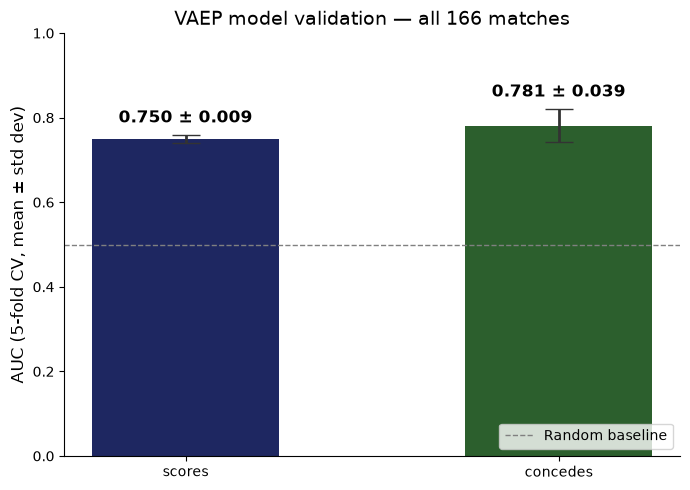

In [60]:
import matplotlib.pyplot as plt; 

fig, ax = plt.subplots(figsize=(7, 5))

model_names = ['scores', 'concedes']
means = [cv_results_ext_means[m] for m in model_names]
stds = [cv_results_ext_stds[m] for m in model_names]
colors = ['#1E2761', '#2C5F2D']

bars = ax.bar(model_names, means, yerr=stds, capsize=10, color=colors, width=0.5,
              error_kw={'elinewidth': 2, 'ecolor': '#333333'})

ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='Random baseline')
ax.set_ylim(0, 1.0)
ax.set_ylabel('AUC (5-fold CV, mean ± std dev)', fontsize=12)
ax.set_title("VAEP model validation: all 166 matches", fontsize=14)

for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.03, f"{m:.3f} ± {s:.3f}", ha='center', fontsize=12, fontweight='bold')

ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
save_fig(plt.gcf(), 'rq1_cv_bar_chart.png')
plt.show()

scores: PR-AUC = 0.189 ± 0.017  (no-skill baseline = 0.0100)
  individual folds: ['0.212', '0.184', '0.175', '0.205', '0.167']
concedes: PR-AUC = 0.084 ± 0.049  (no-skill baseline = 0.0021)
  individual folds: ['0.061', '0.050', '0.050', '0.077', '0.180']
saved ..\data\results\figures\rq1_pr_curves.png


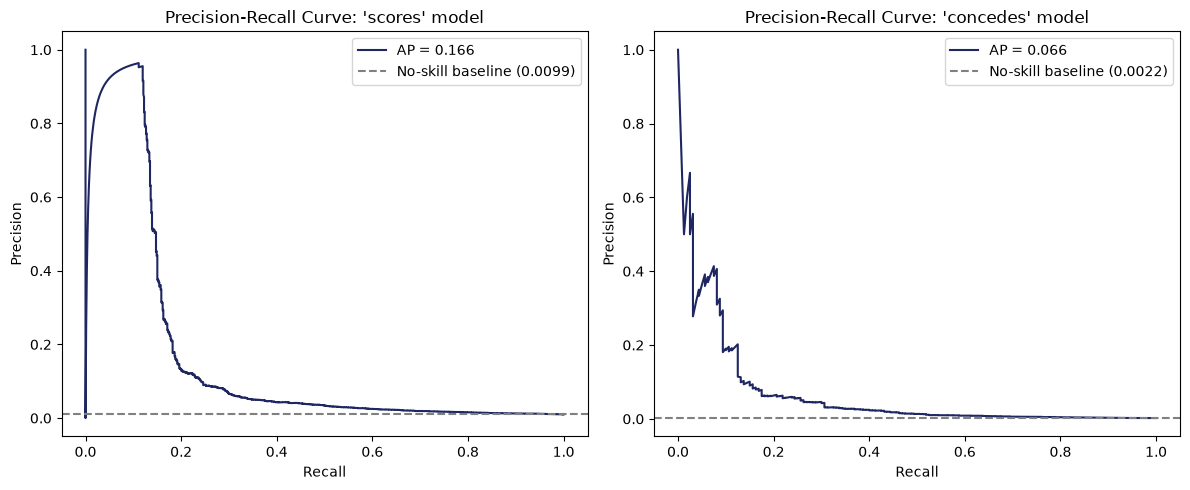

In [61]:
# Precision-Recall AUC is more informative than ROC-AUC for rare positive classes
# (goals conceded are ~0.7% of all actions, so ROC-AUC can look fine while precision-recall tells a more honest story about catching the rare class)

from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

pr_auc_results = {}

for label in ['scores', 'concedes']:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    lr = 0.05 if label == 'concedes' else 0.1
    cv_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=lr, random_state=42)

    cv_scores = cross_val_score(
        cv_model, X_full_ext, Y_full_ext[label], cv=skf, scoring='average_precision'
    )
    pr_auc_results[label] = cv_scores

    baseline = Y_full_ext[label].mean()  # a random/no-skill classifier scores at the positive rate
    print(f"{label}: PR-AUC = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  "
          f"(no-skill baseline = {baseline:.4f})")
    print(f"  individual folds: {[f'{s:.3f}' for s in cv_scores]}")

# Plot precision-recall curves on the held-out test split for a visual complement
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, label in zip(axes, ['scores', 'concedes']):
    preds = models_ext[label].predict_proba(X_test_ext)[:, 1]
    precision, recall, _ = precision_recall_curve(Y_test_ext[label], preds)
    ap = average_precision_score(Y_test_ext[label], preds)
    baseline = Y_test_ext[label].mean()

    ax.plot(recall, precision, label=f'AP = {ap:.3f}')
    ax.axhline(baseline, color='grey', linestyle='--', label=f'No-skill baseline ({baseline:.4f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f"Precision-Recall Curve: '{label}' model")
    ax.legend()

plt.tight_layout()
save_fig(plt.gcf(), 'rq1_pr_curves.png')
plt.show()

### Does the 33.1 percent visibility hold on the larger sample?

This uses only the Layer 1 geometry, with no VAEP involved. The Euro 2024-only result stays as reported either way.

In [62]:
print(f"Extended sample average visibility: {clean_ext['n_visible'].mean() / clean_ext['n_teammates'].mean():.1%}")
print(f"Original Euro-2024-only reported figure: 33.1%")

Extended sample average visibility: 32.3%
Original Euro-2024-only reported figure: 33.1%


### Goal assists in the 115 new matches

The 70 Euro 2024 goal-assist ids are reused; only the new matches are checked, and the two sets are combined.

In [63]:
goal_assist_ids_new = set()
for mid in matches_new['match_id'].tolist():
    m_events = sb.events(match_id=mid)
    if 'pass_goal_assist' in m_events.columns:
        goal_assist_ids_new.update(m_events[m_events['pass_goal_assist'] == True]['id'].tolist())

goal_assist_ids_ext = goal_assist_ids | goal_assist_ids_new
print(f"New goal-assist passes found: {len(goal_assist_ids_new)}")
print(f"Total combined (166 matches): {len(goal_assist_ids_ext)}")

New goal-assist passes found: 203
Total combined (166 matches): 273


### Counterfactual values for all 166 matches

Every match is valued with `models_ext`, trained on all 166 matches, so values are consistent across tournaments. This also reprocesses the 51 Euro 2024 matches, since their earlier values used the smaller model and are not comparable.

Results are saved to a new folder, `../data/counterfactuals_all3/`, so the Euro 2024-only files are not touched. Matches already processed are skipped on a rerun.

In [64]:
all3_match_ids = matches['match_id'].tolist() + matches_new['match_id'].tolist()

# hard duplicate check before starting a multi-hour run
assert len(all3_match_ids) == len(set(all3_match_ids)), "DUPLICATE MATCH IDS FOUND, stop and investigate"
print(f"{len(all3_match_ids)} total matches to process (should be 166)")

166 total matches to process (should be 166)


In [65]:
os.makedirs('../data/counterfactuals_all3', exist_ok=True)
os.makedirs('../data/lstm_eval_all3', exist_ok=True)

def process_match_counterfactuals_all3(mid):
    m_events = sb.events(match_id=mid)
    m_events_oriented = add_orientation_vectors(m_events)
    m_frames = sb.frames(match_id=mid, fmt='dataframe')

    m_actions = actions_full_ext[actions_full_ext['game_id'] == int(mid)].sort_values('action_id').reset_index(drop=True)

    valid_event_ids = set(m_events_oriented[m_events_oriented['orientation_vector'].notna()]['id'])

    qualifying = m_actions[
        (m_actions['type_name'] == 'pass') &
        (m_actions['result_name'] == 'success') &
        (~m_actions['original_event_id'].isin(goal_assist_ids_ext)) &
        (m_actions['original_event_id'].isin(valid_event_ids))
    ]

    results = []
    lstm_eval_rows = []

    for idx in qualifying.index:
        if idx < 2:
            continue

        event_id = m_actions.loc[idx, 'original_event_id']
        teammates = m_frames[
            (m_frames['id'] == event_id) &
            (m_frames['teammate'] == True) &
            (m_frames['actor'] == False)
        ]
        if teammates.empty:
            continue

        matching_event = m_events_oriented[m_events_oriented['id'] == event_id].iloc[0]
        passer_loc = matching_event['location']
        passer_orientation = matching_event['orientation_vector']

        teammates = teammates.copy()
        teammates['angle_to_orientation'] = teammates['location'].apply(
            lambda loc: angle_to_teammate(passer_loc, passer_orientation, loc)
        )
        teammates = teammates.dropna(subset=['angle_to_orientation'])
        if teammates.empty:
            continue
        teammates['visible'] = teammates['angle_to_orientation'] <= 60

        invisible_teammates = teammates[~teammates['visible']]
        for _, inv in invisible_teammates.iterrows():
            lstm_eval_rows.append({
                'match_id': mid, 'original_event_id': event_id,
                'teammate_location': inv['location'], 'passer_location': passer_loc,
                'time_seconds': matching_event.get('timestamp', None)
            })

        context_window = m_actions.loc[idx-2:idx].copy()

        hyp_windows = []
        for _, tm in teammates.iterrows():
            hw = context_window.copy()
            hw.iloc[-1, hw.columns.get_loc('end_x')] = tm['location'][0]
            hw.iloc[-1, hw.columns.get_loc('end_y')] = tm['location'][1]
            hw['visible'] = tm['visible']
            hyp_windows.append(hw)

        hyp_values = []
        for hw in hyp_windows:
            hw_reset = hw.reset_index(drop=True)
            gs = fs.gamestates(hw_reset, nb_prev_actions=3)
            X_hyp = pd.concat([f(gs) for f in feature_functions], axis=1)
            ps = models_ext['scores'].predict_proba(X_hyp)[:, 1]
            pc = models_ext['concedes'].predict_proba(X_hyp)[:, 1]
            v = value(hw_reset, pd.Series(ps), pd.Series(pc)).iloc[-1]['vaep_value']
            hyp_values.append({'visible': hw['visible'].iloc[0], 'value': v})

        hyp_df_row = pd.DataFrame(hyp_values)

        gs_real = fs.gamestates(context_window.reset_index(drop=True), nb_prev_actions=3)
        X_real = pd.concat([f(gs_real) for f in feature_functions], axis=1)
        ps_real = models_ext['scores'].predict_proba(X_real)[:, 1]
        pc_real = models_ext['concedes'].predict_proba(X_real)[:, 1]
        real_value = value(context_window.reset_index(drop=True), pd.Series(ps_real), pd.Series(pc_real)).iloc[-1]['vaep_value']

        visible_only = hyp_df_row[hyp_df_row['visible']]

        results.append({
            'match_id': mid, 'original_event_id': event_id, 'real_value': real_value,
            'best_omniscient_value': hyp_df_row['value'].max(),
            'best_visible_value': visible_only['value'].max() if not visible_only.empty else None,
            'n_candidates': len(hyp_df_row), 'n_visible': int(hyp_df_row['visible'].sum())
        })

    return pd.DataFrame(results), pd.DataFrame(lstm_eval_rows)


failed_all3 = []
for i, mid in enumerate(all3_match_ids):
    save_path = f'../data/counterfactuals_all3/cf_match_{mid}.pkl'
    lstm_save_path = f'../data/lstm_eval_all3/lstm_eval_match_{mid}.pkl'
    if os.path.exists(save_path):
        continue
    try:
        result_df, lstm_eval_df = process_match_counterfactuals_all3(str(mid))
        result_df.to_pickle(save_path)
        lstm_eval_df.to_pickle(lstm_save_path)
        print(f"[{i+1}/{len(all3_match_ids)}] match {mid}: {len(result_df)} passes, {len(lstm_eval_df)} invisible-teammate rows saved")
    except Exception as e:
        print(f"[{i+1}/{len(all3_match_ids)}] match {mid} FAILED: {e}")
        failed_all3.append(mid)

print(f"\nDone. {len(failed_all3)} matches failed: {failed_all3}")


Done. 0 matches failed: []


### The RQ1 result for all 166 matches

In [66]:
cf_files_all3 = glob.glob('../data/counterfactuals_all3/cf_match_*.pkl')
print(f"{len(cf_files_all3)} files (should be 166)")

seen = set()
for f in cf_files_all3:
    mid = f.split('cf_match_')[-1].replace('.pkl', '')
    assert mid not in seen, f"DUPLICATE: {mid}"
    seen.add(mid)
print("Duplicate check passed")

cf_full_all3 = pd.concat([pd.read_pickle(f) for f in cf_files_all3], ignore_index=True)
cf_valid_all3 = cf_full_all3.dropna(subset=['best_visible_value']).copy()

print(f"\nTotal passes with counterfactual comparison: {len(cf_full_all3)}")
print(f"Passes with at least one visible alternative: {len(cf_valid_all3)}")

cf_valid_all3['value_reduction'] = cf_valid_all3['best_omniscient_value'] - cf_valid_all3['best_visible_value']
cf_valid_all3['identity_changes'] = cf_valid_all3['best_omniscient_value'] != cf_valid_all3['best_visible_value']

print(f"\nMean best omniscient value:    {cf_valid_all3['best_omniscient_value'].mean():.5f}")
print(f"Mean best visible-only value:  {cf_valid_all3['best_visible_value'].mean():.5f}")
print(f"Mean reduction after filtering: {cf_valid_all3['value_reduction'].mean():.5f}")
print(f"Proportion where optimal alternative changes: {cf_valid_all3['identity_changes'].mean():.1%}")

diffs_all3 = cf_valid_all3['best_omniscient_value'] - cf_valid_all3['best_visible_value']
d_paired_all3 = diffs_all3.mean() / diffs_all3.std()
print(f"Paired Cohen's d: {d_paired_all3:.3f}")

stat_all3, p_all3 = wilcoxon(cf_valid_all3['best_omniscient_value'], cf_valid_all3['best_visible_value'])
print(f"Wilcoxon: statistic={stat_all3:.1f}, p={p_all3:.2e}")

print(f"\n--- Original Euro-2024-only result, unchanged ---")
print(f"33.1% visibility, 59.1% identity-change, d=0.166")

166 files (should be 166)
Duplicate check passed

Total passes with counterfactual comparison: 98652
Passes with at least one visible alternative: 82045

Mean best omniscient value:    0.01214
Mean best visible-only value:  0.00620
Mean reduction after filtering: 0.00594
Proportion where optimal alternative changes: 58.3%
Paired Cohen's d: 0.281
Wilcoxon: statistic=0.0, p=0.00e+00

--- Original Euro-2024-only result, unchanged ---
33.1% visibility, 59.1% identity-change, d=0.166


### First look at RQ2 on all three tournaments

The same comparison as for Euro 2024: how often was the chosen pass already the best visible option, and how often was a better visible alternative available? Offside and xP are still not applied, so this is an upper bound, not an RQ2 result.

In [67]:
print(f"Mean real pass value:          {cf_valid_all3['real_value'].mean():.5f}")
print(f"Mean best omniscient value:    {cf_valid_all3['best_omniscient_value'].mean():.5f}")
print(f"Mean best visible-only value:  {cf_valid_all3['best_visible_value'].mean():.5f}")

cf_valid_all3['chose_best_visible'] = cf_valid_all3['real_value'] >= cf_valid_all3['best_visible_value']
print(f"\nProportion of passes where the chosen pass was already optimal among visible options: {cf_valid_all3['chose_best_visible'].mean():.1%}")

print(f"\n--- Comparison to original Euro-2024-only result ---")
print(f"Original: 27.2% of passes were already optimal among visible options")

Mean real pass value:          -0.00014
Mean best omniscient value:    0.01214
Mean best visible-only value:  0.00620

Proportion of passes where the chosen pass was already optimal among visible options: 27.5%

--- Comparison to original Euro-2024-only result ---
Original: 27.2% of passes were already optimal among visible options


**Note on the coordinate fix.** The candidate values behind these numbers were computed with a coordinate error, found in `06_layer3_blind_passes.ipynb` and corrected in section 8, where the corrected 166-match results are reported. This cell is kept as the record of the original run.

### Results for all three competitions

The same summary as for Euro 2024, now for the 166 matches. Both results are saved separately, and neither overwrites the other.

In [68]:
rq1_summary_all3 = {
    'total_passes_compared': len(cf_full_all3),
    'passes_with_visible_alternative': len(cf_valid_all3),
    'mean_real_value': cf_valid_all3['real_value'].mean(),
    'mean_omniscient_value': cf_valid_all3['best_omniscient_value'].mean(),
    'mean_visible_value': cf_valid_all3['best_visible_value'].mean(),
    'mean_reduction': cf_valid_all3['value_reduction'].mean(),
    'proportion_identity_changed': cf_valid_all3['identity_changes'].mean(),
    'proportion_chose_best_visible': cf_valid_all3['chose_best_visible'].mean(),
    'paired_cohens_d': d_paired_all3,
    'wilcoxon_statistic': stat_all3,
    'wilcoxon_pvalue': p_all3,
    'n_matches': 166,
    'competitions': ['Euro 2024', 'Euro 2020', 'World Cup 2022']
}

cf_valid_all3.to_pickle('../data/results/rq1_counterfactual_comparison_all3.pkl')
pd.to_pickle(rq1_summary_all3, '../data/results/rq1_summary_stats_all3.pkl')

print("Saved. RQ1 summary (all 3 competitions):")
for k, v in rq1_summary_all3.items():
    print(f"  {k}: {v}")

Saved. RQ1 summary (all 3 competitions):
  total_passes_compared: 98652
  passes_with_visible_alternative: 82045
  mean_real_value: -0.0001423075089771079
  mean_omniscient_value: 0.012138766553810972
  mean_visible_value: 0.006198432326095656
  mean_reduction: 0.0059403342277153165
  proportion_identity_changed: 0.582619294289719
  proportion_chose_best_visible: 0.2747150953744896
  paired_cohens_d: 0.28088764593715243
  wilcoxon_statistic: 0.0
  wilcoxon_pvalue: 0.0
  n_matches: 166
  competitions: ['Euro 2024', 'Euro 2020', 'World Cup 2022']


### Saving every candidate for RQ2

The per-pass summary keeps only the best visible value, and drops each candidate's value, location and visibility. RQ2 needs that detail to check offside, compute xP, and decide whether each candidate is a maximal-VAEP option compared with the real pass. A second file per match keeps the full breakdown, using the same VAEP calculation.

In [69]:
os.makedirs('../data/candidates_all3', exist_ok=True)

def process_match_candidates_all3(mid):
    m_events = sb.events(match_id=mid)
    m_events_oriented = add_orientation_vectors(m_events)
    m_frames = sb.frames(match_id=mid, fmt='dataframe')

    m_actions = actions_full_ext[actions_full_ext['game_id'] == int(mid)].sort_values('action_id').reset_index(drop=True)

    valid_event_ids = set(m_events_oriented[m_events_oriented['orientation_vector'].notna()]['id'])

    qualifying = m_actions[
        (m_actions['type_name'] == 'pass') &
        (m_actions['result_name'] == 'success') &
        (~m_actions['original_event_id'].isin(goal_assist_ids_ext)) &
        (m_actions['original_event_id'].isin(valid_event_ids))
    ]

    candidate_rows = []

    for idx in qualifying.index:
        if idx < 2:
            continue

        event_id = m_actions.loc[idx, 'original_event_id']
        teammates = m_frames[
            (m_frames['id'] == event_id) &
            (m_frames['teammate'] == True) &
            (m_frames['actor'] == False)
        ]
        if teammates.empty:
            continue

        matching_event = m_events_oriented[m_events_oriented['id'] == event_id].iloc[0]
        passer_loc = matching_event['location']
        passer_orientation = matching_event['orientation_vector']

        teammates = teammates.copy()
        teammates['angle_to_orientation'] = teammates['location'].apply(
            lambda loc: angle_to_teammate(passer_loc, passer_orientation, loc)
        )
        teammates = teammates.dropna(subset=['angle_to_orientation'])
        if teammates.empty:
            continue
        teammates['visible'] = teammates['angle_to_orientation'] <= 60

        context_window = m_actions.loc[idx-2:idx].copy()

        real_end_x = m_actions.loc[idx, 'end_x']
        real_end_y = m_actions.loc[idx, 'end_y']

        for _, tm in teammates.iterrows():
            hw = context_window.copy()
            hw.iloc[-1, hw.columns.get_loc('end_x')] = tm['location'][0]
            hw.iloc[-1, hw.columns.get_loc('end_y')] = tm['location'][1]

            hw_reset = hw.reset_index(drop=True)
            gs = fs.gamestates(hw_reset, nb_prev_actions=3)
            X_hyp = pd.concat([f(gs) for f in feature_functions], axis=1)
            ps = models_ext['scores'].predict_proba(X_hyp)[:, 1]
            pc = models_ext['concedes'].predict_proba(X_hyp)[:, 1]
            v = value(hw_reset, pd.Series(ps), pd.Series(pc)).iloc[-1]['vaep_value']

            candidate_rows.append({
                'match_id': mid,
                'original_event_id': event_id,
                'passer_location': passer_loc,
                'candidate_location': tm['location'],
                'visible': bool(tm['visible']),
                'candidate_value': v,
                'real_end_x': real_end_x,
                'real_end_y': real_end_y,
            })

    return pd.DataFrame(candidate_rows)


failed_candidates = []
for i, mid in enumerate(all3_match_ids):
    save_path = f'../data/candidates_all3/candidates_match_{mid}.pkl'
    if os.path.exists(save_path):
        continue
    try:
        cand_df = process_match_candidates_all3(str(mid))
        cand_df.to_pickle(save_path)
        print(f"[{i+1}/{len(all3_match_ids)}] match {mid}: {len(cand_df)} candidate rows saved")
    except Exception as e:
        print(f"[{i+1}/{len(all3_match_ids)}] match {mid} FAILED: {e}")
        failed_candidates.append(mid)

print(f"\nDone. {len(failed_candidates)} matches failed: {failed_candidates}")


Done. 0 matches failed: []


## 8. The coordinate fix: recomputing candidate values in SPADL coordinates

The candidate values above were computed by placing each teammate's freeze-frame position (StatsBomb yards, passing team attacking toward x = 120) directly into the end location of a SPADL action (metres, with every away-team action flipped). `06_layer3_blind_passes.ipynb` confirmed the mismatch and showed it changes the RQ2 result.

This section recomputes every candidate value after converting the freeze-frame position into SPADL coordinates for the passing team's direction of play. It uses the VAEP models rebuilt and saved in `06_layer3_blind_passes.ipynb`, which reproduce the models above exactly. The corrected candidates are saved to a new folder, so the original files stay as they were, and the RQ1 results are rebuilt from them.

Two further changes:

- the value of the real pass is stored for every pass, including passes where no teammate was visible;
- the old (incorrect) value is kept in a column called `candidate_value_old` for comparison.

These cells are self-contained and can be run without rerunning the rest of the notebook.

In [70]:
import os
import glob
import pickle
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import socceraction.vaep.features as fs
from socceraction.vaep.formula import value
from scipy.stats import wilcoxon

feature_functions = [
    fs.actiontype_onehot,
    fs.result_onehot,
    fs.startlocation,
    fs.endlocation,
    fs.team,
    fs.time_delta,
]

# the rebuilt VAEP models from 06_layer3_blind_passes.ipynb, identical to models_ext above
with open('../data/results/vaep_models_ext.pkl', 'rb') as f:
    models_ext = pickle.load(f)

# keep a copy of the pre-fix candidate table before layer 2 overwrites it,
# since the checks in 06_layer3_blind_passes.ipynb compare against it
old_path = Path('../data/results/candidates_full.pkl')
backup_path = Path('../data/results/candidates_full_old_coords.pkl')
if old_path.exists() and not backup_path.exists():
    shutil.copy(old_path, backup_path)
print(f"pre-fix candidate table kept at {backup_path}: {backup_path.exists()}")


def load_match_actions(mid):
    """The SPADL actions saved for this match earlier in this notebook, in action order."""
    for folder in ['../data/matches', '../data/matches_extended']:
        p = Path(folder) / f'match_{mid}.pkl'
        if p.exists():
            return pd.read_pickle(p)['actions'].sort_values('action_id').reset_index(drop=True)
    raise FileNotFoundError(f"no saved actions for match {mid}")


def batch_window_values(m_actions, pass_idx, end_x, end_y, models):
    """VAEP value of the last action in each 3-action window m_actions.loc[i-2:i],
    with that action's end moved to (end_x, end_y). Same numbers as the one-window-at-a-time
    loop above, including socceraction's padding at the start of a window or period."""
    pass_idx = np.asarray(pass_idx)
    n = len(pass_idx)
    r0 = m_actions.loc[pass_idx - 2].reset_index(drop=True)
    r1 = m_actions.loc[pass_idx - 1].reset_index(drop=True)
    r2 = m_actions.loc[pass_idx].reset_index(drop=True)
    r2['end_x'] = np.asarray(end_x, dtype=float)
    r2['end_y'] = np.asarray(end_y, dtype=float)
    rows = pd.concat([r0, r1, r2], ignore_index=True)   # row number = role * n + window

    w = np.arange(n)
    i0, i1, i2 = w, n + w, 2 * n + w
    same01 = r0['period_id'].values == r1['period_id'].values
    same12 = r1['period_id'].values == r2['period_id'].values

    cur = np.column_stack([i1, i2]).ravel()
    prev1 = np.column_stack([np.where(same01, i0, i1),
                             np.where(same12, i1, i2)]).ravel()
    prev2 = np.column_stack([np.where(same01, i0, i1),
                             np.where(same12, np.where(same01, i0, i1), i2)]).ravel()

    gs = [rows.iloc[ix].reset_index(drop=True) for ix in (cur, prev1, prev2)]
    X = pd.concat([f(gs) for f in feature_functions], axis=1)
    ps = models['scores'].predict_proba(X)[:, 1]
    pc = models['concedes'].predict_proba(X)[:, 1]
    v = value(gs[0], pd.Series(ps), pd.Series(pc))['vaep_value'].values
    return v[1::2]


def sb_to_spadl(x, y, mirrored):
    """StatsBomb yards (acting team attacking toward x=120) to SPADL metres,
    with socceraction's flip for away-team actions."""
    x = np.clip((np.asarray(x, dtype=float) - 0.5) / 120 * 105, 0, 105)
    y = np.clip(68 - (np.asarray(y, dtype=float) - 0.5) / 80 * 68, 0, 68)
    mirrored = np.asarray(mirrored, dtype=bool)
    return np.where(mirrored, 105 - x, x), np.where(mirrored, 68 - y, y)

pre-fix candidate table kept at ..\data\results\candidates_full_old_coords.pkl: True


Before anything is recomputed, the candidate table saved by Layer 2 (`candidates_full.pkl`) is copied to `candidates_full_old_coords.pkl`. Layer 2 overwrites `candidates_full.pkl` when it is rerun on the corrected values, and the checks in `06_layer3_blind_passes.ipynb` need the original values. The copy is made only once, so rerunning this cell never replaces the original with corrected values.

In [71]:
FIXED_DIR = Path('../data/candidates_all3_fixed')
FIXED_DIR.mkdir(parents=True, exist_ok=True)

candidate_files = sorted(glob.glob('../data/candidates_all3/candidates_match_*.pkl'))
print(f"{len(candidate_files)} candidate files (should be 166)")

checks = []
t0 = time.time()
for i, f in enumerate(candidate_files):
    mid = f.split('candidates_match_')[-1].replace('.pkl', '')
    c = pd.read_pickle(f)
    m_actions = load_match_actions(mid)

    # the SPADL row of each pass
    pass_rows = m_actions[m_actions['type_name'] == 'pass']
    idx_of = pd.Series(pass_rows.index, index=pass_rows['original_event_id'])
    idx_of = idx_of[~idx_of.index.duplicated()]
    pass_idx = c['original_event_id'].map(idx_of)
    assert pass_idx.notna().all(), f"match {mid}: a candidate's pass is missing from the SPADL actions"
    pass_idx = pass_idx.astype(int).to_numpy()

    # which team is mirrored (the away team): the conversion of the passer's StatsBomb
    # location that lands closer to the SPADL start of the same pass, per team
    team = m_actions.loc[pass_idx, 'team_id'].to_numpy()
    start_x = m_actions.loc[pass_idx, 'start_x'].to_numpy()
    px, py = c['passer_location'].str[0], c['passer_location'].str[1]
    as_home, _ = sb_to_spadl(px, py, False)
    as_away, _ = sb_to_spadl(px, py, True)
    err = pd.DataFrame({'team': team,
                        'home': np.abs(start_x - as_home),
                        'away': np.abs(start_x - as_away)}).groupby('team').median()
    mirrored_ids = set(err.index[err['away'] < err['home']])
    c['mirrored'] = np.isin(team, list(mirrored_ids))

    cx, cy = c['candidate_location'].str[0], c['candidate_location'].str[1]

    # the old calculation, rebuilt only to confirm it reproduces the stored values
    old_rebuilt = batch_window_values(m_actions, pass_idx, cx, cy, models_ext)

    # the corrected candidate values
    sx, sy = sb_to_spadl(cx, cy, c['mirrored'])
    c['candidate_value_old'] = c['candidate_value']
    c['candidate_value'] = batch_window_values(m_actions, pass_idx, sx, sy, models_ext)

    # the real pass's value, now for every pass (the old table only had it for passes with a visible teammate)
    uniq = np.unique(pass_idx)
    rv = batch_window_values(m_actions, uniq, m_actions.loc[uniq, 'end_x'], m_actions.loc[uniq, 'end_y'], models_ext)
    c['real_value'] = pd.Series(rv, index=uniq).loc[pass_idx].to_numpy()

    c.to_pickle(FIXED_DIR / f'candidates_match_{mid}.pkl')
    checks.append({'match_id': mid, 'rows': len(c), 'mirrored_teams': len(mirrored_ids),
                   'max_old_diff': np.abs(old_rebuilt - c['candidate_value_old'].to_numpy()).max()})
    if (i + 1) % 20 == 0:
        print(f"[{i+1}/{len(candidate_files)}] matches done ({time.time() - t0:.0f}s)")

checks = pd.DataFrame(checks)
print(f"\nDone in {time.time() - t0:.0f}s, {checks['rows'].sum()} candidate rows")
print(f"matches with exactly one mirrored team: {(checks['mirrored_teams'] == 1).sum()} of {len(checks)}")
print(f"largest difference between rebuilt and stored old values: {checks['max_old_diff'].max():.2e}")

166 candidate files (should be 166)
[20/166] matches done (4s)
[40/166] matches done (8s)
[60/166] matches done (12s)
[80/166] matches done (15s)
[100/166] matches done (19s)
[120/166] matches done (23s)
[140/166] matches done (27s)
[160/166] matches done (31s)

Done in 32s, 664510 candidate rows
matches with exactly one mirrored team: 166 of 166
largest difference between rebuilt and stored old values: 0.00e+00


**What this shows**

**Every candidate was recomputed.** All 166 matches were processed and all 664510 candidate rows were matched to their SPADL pass.

**Only the coordinates changed.** Two checks confirm it:

- every match has exactly one mirrored team, the away team, which is what socceraction's direction-of-play flip produces;
- recomputing the old values with the old, unconverted coordinates reproduces every stored value exactly (largest difference 0) across all 166 matches.

So the models, the batched calculation and the matching of candidates to passes are identical to the original run, and the only difference in the corrected values is the coordinate conversion.

In [72]:
cands_fixed = pd.concat([pd.read_pickle(f) for f in sorted(glob.glob(str(FIXED_DIR / 'candidates_match_*.pkl')))],
                        ignore_index=True)


def rq1_table(c, value_col):
    """One row per pass, as in the RQ1 counterfactual files: real value, best option overall, best visible option."""
    c = c.assign(_v=c[value_col], _vis=c[value_col].where(c['visible']))
    return c.groupby(['match_id', 'original_event_id']).agg(
        real_value=('real_value', 'first'),
        best_omniscient_value=('_v', 'max'),
        best_visible_value=('_vis', 'max'),
        n_candidates=('_v', 'size'),
        n_visible=('visible', 'sum'),
    ).reset_index()


def rq1_stats(t):
    v = t.dropna(subset=['best_visible_value']).copy()
    v['value_reduction'] = v['best_omniscient_value'] - v['best_visible_value']
    v['identity_changes'] = v['best_omniscient_value'] != v['best_visible_value']
    v['chose_best_visible'] = v['real_value'] >= v['best_visible_value']
    stat, p = wilcoxon(v['best_omniscient_value'], v['best_visible_value'])
    summary = {
        'total_passes_compared': len(t),
        'passes_with_visible_alternative': len(v),
        'mean_real_value': v['real_value'].mean(),
        'mean_omniscient_value': v['best_omniscient_value'].mean(),
        'mean_visible_value': v['best_visible_value'].mean(),
        'mean_reduction': v['value_reduction'].mean(),
        'proportion_identity_changed': v['identity_changes'].mean(),
        'proportion_chose_best_visible': v['chose_best_visible'].mean(),
        'paired_cohens_d': v['value_reduction'].mean() / v['value_reduction'].std(),
        'wilcoxon_statistic': stat,
        'wilcoxon_pvalue': p,
        'n_matches': t['match_id'].nunique(),
        'competitions': ['Euro 2024', 'Euro 2020', 'World Cup 2022'],
    }
    return v, summary


cf_valid_old, summary_old = rq1_stats(rq1_table(cands_fixed, 'candidate_value_old'))
cf_valid_fixed, summary_fixed = rq1_stats(rq1_table(cands_fixed, 'candidate_value'))

show = ['total_passes_compared', 'passes_with_visible_alternative', 'mean_real_value',
        'mean_omniscient_value', 'mean_visible_value', 'mean_reduction',
        'proportion_identity_changed', 'proportion_chose_best_visible', 'paired_cohens_d']
print("RQ1, old coordinates (should match the results above) against corrected coordinates:")
print(pd.DataFrame({'old': summary_old, 'fixed': summary_fixed}).loc[show].to_string())

cf_valid_fixed.to_pickle('../data/results/rq1_counterfactual_comparison_all3_fixed.pkl')
pd.to_pickle(summary_fixed, '../data/results/rq1_summary_stats_all3_fixed.pkl')
print("\nSaved rq1_counterfactual_comparison_all3_fixed.pkl and rq1_summary_stats_all3_fixed.pkl")

RQ1, old coordinates (should match the results above) against corrected coordinates:
                                      old     fixed
total_passes_compared               98652     98652
passes_with_visible_alternative     82045     82045
mean_real_value                 -0.000142 -0.000142
mean_omniscient_value            0.012139  0.004848
mean_visible_value               0.006198   0.00162
mean_reduction                    0.00594  0.003228
proportion_identity_changed      0.582619   0.57889
proportion_chose_best_visible    0.274715  0.361472
paired_cohens_d                  0.280888  0.282416

Saved rq1_counterfactual_comparison_all3_fixed.pkl and rq1_summary_stats_all3_fixed.pkl


## Summary: the corrected RQ1 result

**The original results are reproduced.** The "old" column matches the original results exactly:

- 98652 passes, 82045 with a visible alternative;
- 58.3 percent identity changes and d = 0.281;
- 27.5 percent chose the best visible option.

So rebuilding the per-pass table from the candidate files is equivalent to the original RQ1 calculation. The "fixed" column is the corrected result.

**The headline RQ1 finding holds.** Restricting the comparison to teammates inside the 120 degree vision cone changes the best alternative in 57.9 percent of the 82045 passes with at least one visible alternative (58.3 percent before the fix). The paired effect size is essentially unchanged at d = 0.282 (0.281 before). Both the omniscient and the visible best values were inflated by the coordinate error, so the comparison between them was affected far less than the values themselves.

**The values themselves are smaller:**

| | Before the fix | After the fix |
|---|---|---|
| Mean best omniscient value | 0.0121 | 0.0048 |
| Mean best visible value | 0.0062 | 0.0016 |
| Mean reduction from the vision cone | 0.0059 | 0.0032 |

The old values placed many hypothetical passes further up the pitch than the teammate really stood, or on the wrong side of it, which made alternatives look more valuable than they were.

**The chosen pass looks better.** The pass actually made was already at least as valuable as every visible alternative in 36.1 percent of passes, up from 27.5 percent. Put the other way, a higher-valued visible alternative existed in 63.9 percent of passes, down from 72.5 percent. This is still not filtered for offside and pass difficulty, which Layer 2 adds.

**Corrected RQ1 result:**

- 98652 passes compared across 166 matches, 82045 with at least one visible alternative;
- the vision cone changes the best alternative in 57.9 percent of them;
- mean value reduction 0.0032, paired Cohen's d = 0.282, Wilcoxon p < 0.0001.

Saved as `rq1_counterfactual_comparison_all3_fixed.pkl` and `rq1_summary_stats_all3_fixed.pkl`, which Layer 2 loads.

**Checked against tracking.** `14_layer3_pff_facing_check.ipynb` rebuilds the cone from PFF tracking for the World Cup passes. The two cones agree on 73 percent of teammates, and the RQ1 result is unchanged on the same passes (58.7 percent with the StatsBomb cone, 58.2 percent with the PFF cone).